# Structure from Motion (SfM)

**Задача SfM:** по набору снимков статичной сцены, сделанных с разных ракурсов, одновременно восстановить
* **движение (motion)** — позы камер $(R_i, \mathbf{t}_i)$ всех кадров;
* **структуру (structure)** — 3D-координаты точек сцены $\mathbf{X}_k$.

Вход — только изображения (у нас ещё известная калибровка $K$). Кадры связываются через сопоставление особых точек:
одна точка сцены, найденная на нескольких снимках, образует **трек**. Результат определён с точностью до подобия (поворот, сдвиг и масштаб всей сцены): без известного расстояния — размера объекта в сцене или длины базы между двумя камерами — масштаб неизвестен.

## Incremental SfM

Реконструкция начинается с пары кадров и наращивается по одному кадру, с регулярным уточнением.

```
ключевые кадры
   ─► особые точки + сопоставления, геометрическая верификация (RANSAC по F/E/H)
   ─► инициализация по паре кадров (E → R,t → триангуляция → BA двух видов)
   ─► ┌──────────────── цикл, пока есть кадры ──────────────────┐
      │ выбор следующего кадра (больше всего 2D–3D соответствий)│
      │   ─► PnP + RANSAC (+ нелинейное уточнение позы)         │
      │   ─► триангуляция новых точек                           │
      │   ─► локальный BA (новый кадр + соседи)                 │
      │   ─► фильтрация выбросов (ошибка репроекции, угол, z>0) │
      │   ─► иногда глобальный BA + ретриангуляция              │
      └─────────────────────────────────────────────────────────┘
   ─► финальный глобальный BA
   ─► получаем разреженное облако + позы камер
   ─► плотное облако: ректификация пар + SGBM ─► карты глубины ─► слияние/фильтрация
```

**PnP (Perspective-n-Point)** — поиск позы $(R, \mathbf{t})$ камеры по соответствиям «2D-точка кадра ↔ известная 3D-точка»
при известной $K$. Минимально нужно 3 точки (P3P); на практике — с RANSAC для отсева выбросов.

**Bundle adjustment (BA)** — совместное нелинейное уточнение поз камер и 3D-точек сразу по нескольким кадрам.
* **Известно (фиксировано):** наблюдения $\mathbf{x}_{ik}$ — пиксели точки $k$ в кадре $i$ (треки), и калибровка $K$.
* **Уточняем:** позы камер $(R_i, \mathbf{t}_i)$ и 3D-точки $\mathbf{X}_k$ — у каждой точки одна 3D-координата на все кадры,
  где она видна. Начальные значения берутся из PnP и триангуляции.
* **Минимизируем** суммарную ошибку репроекции по всем наблюдениям:
$$\min_{\{R_i,\,\mathbf{t}_i\},\,\{\mathbf{X}_k\}} \sum_{(i,k)} \big\| \mathbf{x}_{ik} - \pi(K, R_i, \mathbf{t}_i, \mathbf{X}_k) \big\|^2,$$
где $\pi$ — проекция. Локальный BA уточняет новый кадр и его соседей, глобальный — всю реконструкцию.

### Почему недостаточно добавления новых точек с нового кадра (PnP + триангуляция)

PnP и триангуляция — **локальные жадные** оценки: каждая уточняет одну группу параметров, считая другую точной,
и использует только часть наблюдений.

1. **Каждый шаг доверяет неточным данным.** PnP считает 3D-точки точными, триангуляция — позы. Ошибки одних
   переходят в другие, и ни один шаг не может поправить то, что считает фиксированным.
2. **Ошибки накапливаются (дрейф).** Новый кадр опирается на предыдущие, а ранние оценки без BA никогда не пересматриваются.
   При обходе объекта по кругу из-за дрейфа траектория положений центров камер не замыкается.
3. **Используются не все наблюдения.** Точка триангулируется по двум кадрам, хотя потом видна в 5–10.
4. **Минимизируется не та ошибка.** DLT-триангуляция и линейный PnP минимизируют алгебраическую ошибку
   (ошибку в пикселях, умноженную на глубину), а не ошибку репроекции в пикселях.

Поэтому PnP и триангуляция дают **начальное приближение**, а BA уточняет всё совместно по всем наблюдениям.

In [1]:
from itertools import combinations
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from scipy.optimize import least_squares
from scipy.sparse import coo_matrix

# import plotly.io as pio; pio.renderers.default = "browser"   # раскомментируйте, если 3D-графики не отображаются в IDE
%config InlineBackend.figure_formats = ["jpeg"]
plt.rcParams["figure.dpi"] = 100
np.set_printoptions(precision=4, suppress=True)

assert tuple(map(int, cv2.__version__.split(".")[:2])) >= (4, 8), "нужен OpenCV >= 4.8 (новый API ChArUco)"
print("OpenCV", cv2.__version__)

OpenCV 5.0.0


In [2]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".ppm", ".bmp", ".tif", ".tiff"}
VIDEO_EXT = {".mp4", ".mov", ".m4v", ".avi", ".mkv"}


def to_work_size(img):
    s = WORK_MAX_SIDE / max(img.shape[:2])
    return cv2.resize(img, None, fx=s, fy=s, interpolation=cv2.INTER_AREA) if s < 1 else img


def load_frames(path, fps=1, max_frames=int(1e5)):
    """Кадры из видео (fps штук в секунду) или все изображения из папки (в алфавитном порядке).
    Возвращает (names, images): images — RGB-кадры в рабочем разрешении."""
    path = Path(path)
    names, images = [], []
    if path.is_dir():
        heic = [p.name for p in path.iterdir() if p.suffix.lower() in {".heic", ".heif"}]
        if heic:
            print(f"пропущено {len(heic)} HEIC-файлов: OpenCV их не читает, снимайте в JPEG («Наиболее совместимый»)")
        for p in sorted(p for p in path.iterdir() if p.suffix.lower() in IMG_EXT)[:max_frames]:
            img = cv2.imread(str(p))                        # поворот по EXIF применяется автоматически
            names.append(p.name)
            images.append(to_work_size(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)))
    elif path.suffix.lower() in VIDEO_EXT and path.exists():
        cap = cv2.VideoCapture(str(path))
        assert cap.isOpened(), f"не удалось открыть {path}"
        video_fps = cap.get(cv2.CAP_PROP_FPS) or 30
        step = max(1, round(video_fps / fps))
        k = 0
        while len(images) < max_frames and cap.grab():
            if k % step == 0:
                _, frame = cap.retrieve()
                names.append(f"{path.stem}_{k:05d}")
                images.append(to_work_size(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
            k += 1
        cap.release()
        print(f"{path.name}: {video_fps:.0f} кадров/с, {k} кадров ({k / video_fps:.0f} с), взят каждый {step}-й")
    else:
        raise FileNotFoundError(f"{path}: нужна папка с фото или видеофайл ({', '.join(sorted(VIDEO_EXT))})")
    assert images, f"{path}: не найдено ни одного кадра"
    sizes = {im.shape[:2] for im in images}
    assert len(sizes) == 1, f"кадры разного размера {sizes}: снимайте в одной ориентации и одном разрешении"
    return names, images


def show_grid(images, titles=None, ncols=6, width=16):
    nrows = int(np.ceil(len(images) / ncols))
    h, w = images[0].shape[:2]
    fig, axes = plt.subplots(nrows, ncols, figsize=(width, width / ncols * h / w * nrows + 0.3 * nrows), squeeze=False)
    for a in axes.ravel():
        a.axis("off")
    for k, im in enumerate(images):
        axes.ravel()[k].imshow(im, cmap="gray")
        if titles is not None:
            axes.ravel()[k].set_title(str(titles[k]), fontsize=8)
    plt.tight_layout(); plt.show()

### Загрузите изображения в "assets/fountain-P11/images" отсюда: https://documents.epfl.ch/groups/c/cv/cvlab-unit/www/data/multiview/data/fountain_dense/urd/fountain_dense_images.tar.gz



размер кадров: (3072, 2048)
K =  [[2759.48    0.   1520.69]
 [   0.   2764.16 1006.81]
 [   0.      0.      1.  ]]
dist =  [0 0 0 0 0]


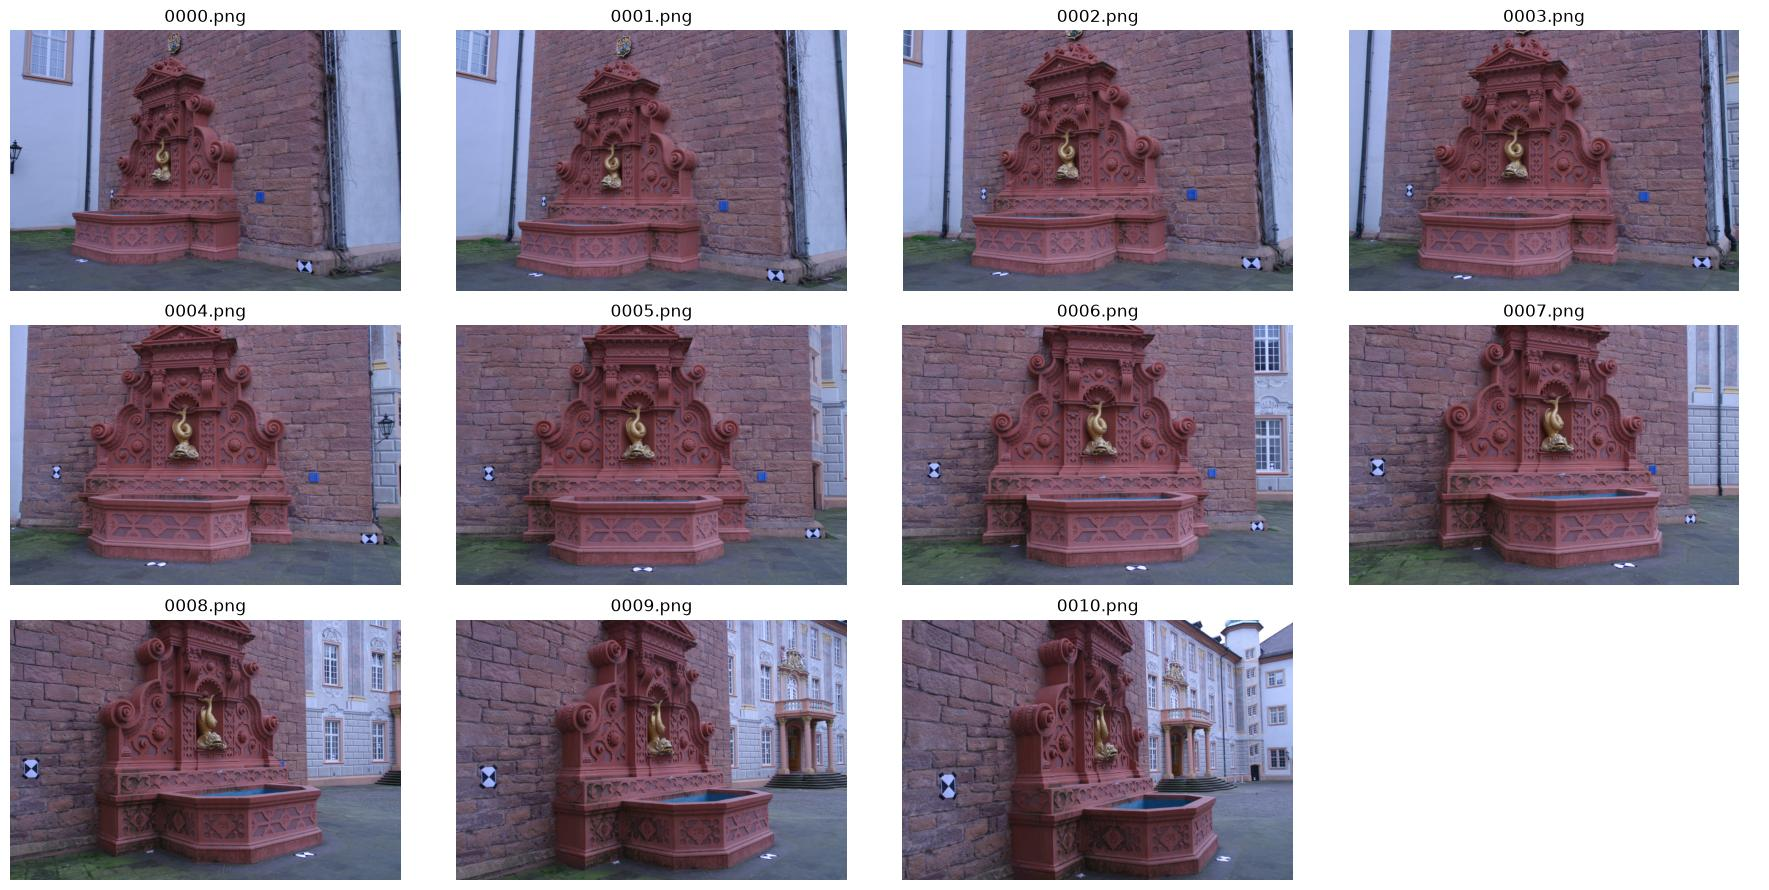

In [3]:
SCENE_INPUT = "assets/fountain-P11/images"
WORK_MAX_SIDE = 3072      # кадры уменьшаются так, чтобы большая сторона была не больше этого числа


scene_names, scene_frames = load_frames(SCENE_INPUT)


SCALE = min(WORK_MAX_SIDE / 3072, 1)
# внутренние параметры камеры (одна камера для обоих снимков), пересчитанные под SCALE
K = np.diag([SCALE, SCALE, 1.0]) @ np.array([
    [2759.48,    0.0,  1520.69],
    [   0.0,  2764.16, 1006.81],
    [   0.0,     0.0,     1.0 ],
])
K_inv = np.linalg.inv(K)
print("размер кадров:", (scene_frames[0].shape[1], scene_frames[0].shape[0]))
print("K = ", K)
# Коэффициенты дисторсии
dist = np.array([0, 0, 0, 0, 0])
print("dist = ", dist)


OUT_DIR = Path("outputs/fountain-P11")
OUT_DIR.mkdir(parents=True, exist_ok=True)


fig, axes = plt.subplots(3, 4, figsize=(18, 9))
for ax in axes.flat:
    ax.axis("off")
for ax, img, name in zip(axes.flat, scene_frames, scene_names):
    ax.imshow(img); ax.set_title(name)
plt.tight_layout(); plt.show()

## Особые точки и сопоставления

Этап выполняется **один раз до реконструкции**: дальше пайплайн работает только с его результатами.

**1. Особые точки** — `extract_features`, для каждого кадра:
* **SIFT**: детектор находит точки (положение, масштаб, ориентация), дескриптор — вектор из 128 чисел
  (гистограммы направлений градиентов в окрестности точки), устойчивый к масштабу, повороту и яркости;
* координаты точек сразу **исправляются за дисторсию** (`cv2.undistortPoints(..., P=K)`): дальше весь пайплайн работает
  с идеальной камерой-обскурой $K$;
* цвет пикселя сохраняется для раскраски облака.

**2. Пары кадров** — `make_pairs`: каждый кадр сопоставляется с `window = 2` соседями в каждую сторону.
Все пары — это $O(n^2)$: для 100 кадров почти 5000 пар. При съёмке по кругу добавляют ещё пары между далёкими кадрами,
чтобы замкнуть петлю.

**3. Сопоставление пары** — `match_pair`:
1. для каждого дескриптора кадра a — два ближайших в кадре b (`FLANN.knnMatch`, k=2) и **ratio test** Лоу:
   лучший кандидат должен быть заметно ближе второго;
2. **однозначность**: каждая точка кадра b используется не больше одного раза (иначе у трека будет два наблюдения в одном кадре);
3. **геометрическая проверка**: `cv2.findEssentialMat` + MAGSAC (порог ~1 px) — остаются только соответствия,
   согласованные с эпиполярной геометрией;
4. если инлаеров меньше `min_inliers`, пара отбрасывается.

**Результат этапа:**

| переменная | размер | что хранит |
|---|---|---|
| `feats[i]["pts"]` | $(N_i, 2)$ | координаты особых точек кадра $i$ без дисторсии, px |
| `feats[i]["desc"]` | $(N_i, 128)$ | SIFT-дескрипторы |
| `feats[i]["colors"]` | $(N_i, 3)$ | RGB-цвет точки |
| `matches[(i, j)]` | $(M_{ij}, 2)$ | индексы сопоставленных особых точек: `[:, 0]` — в кадре $i$, `[:, 1]` — в кадре $j$ (только пары, прошедшие проверку) |

Индекс особой точки (номер строки в `feats[i]["pts"]`) — её идентификатор во всём пайплайне: по нему из попарных
соответствий собираются треки.

In [4]:
SIFT = cv2.SIFT_create(nfeatures=8000, contrastThreshold=0.01)   # порог ниже стандартного 0.04 — больше точек на слабоконтрастных поверхностях


def extract_features(image, K, dist):
    """Особые точки кадра: dict(pts (N, 2) — без дисторсии, desc (N, 128), colors (N, 3))."""
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    keypoints, descriptors = SIFT.detectAndCompute(gray, None)
    points = np.float32([kp.pt for kp in keypoints]).reshape(-1, 2)

    pixels = np.clip(np.round(points).astype(int), 0, [image.shape[1] - 1, image.shape[0] - 1])
    colors = image[pixels[:, 1], pixels[:, 0]]

    points_undist = cv2.undistortPoints(points.reshape(-1, 1, 2), K, dist, P=K).reshape(-1, 2).astype(np.float64)
    return dict(pts=points_undist, desc=descriptors, colors=colors)


feats = [extract_features(frame, K, dist) for frame in scene_frames]
print("особых точек на кадр:", [len(f["pts"]) for f in feats])

особых точек на кадр: [8000, 8000, 8001, 8000, 8001, 8000, 8000, 8000, 8000, 8000, 8000]


In [5]:
FLANN = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=64))   # приближённый поиск соседей по kd-деревьям


def match_pair(feat_a, feat_b, K, ratio=0.8, ransac_px=1.0, min_inliers=20):
    """Проверенные соответствия кадров a и b: массив (M, 2) индексов особых точек или None."""
    if feat_a["desc"] is None or feat_b["desc"] is None or len(feat_a["desc"]) < 2 or len(feat_b["desc"]) < 2:
        return None

    # 1. два ближайших соседа + ratio test: (индекс в a, индекс в b, расстояние)
    knn = FLANN.knnMatch(feat_a["desc"], feat_b["desc"], k=2)
    candidates = np.array([(best.queryIdx, best.trainIdx, best.distance)
                           for best, second in (nn for nn in knn if len(nn) == 2)
                           if best.distance < ratio * second.distance]).reshape(-1, 3)
    if len(candidates) < min_inliers:
        return None

    # 2. однозначность: если точку b выбрали несколько раз, оставляем самое близкое соответствие
    candidates = candidates[np.argsort(candidates[:, 2])]
    _, first_occurrence = np.unique(candidates[:, 1], return_index=True)
    matched_idx = candidates[first_occurrence, :2].astype(int)

    # 3. геометрическая проверка: соответствия должны согласовываться с одной матрицей E
    E, inlier_mask = cv2.findEssentialMat(feat_a["pts"][matched_idx[:, 0]], feat_b["pts"][matched_idx[:, 1]], K,
                                          method=cv2.USAC_MAGSAC, prob=0.999, threshold=ransac_px)
    if E is None:
        return None
    inliers = inlier_mask.ravel() > 0

    # 4. слишком мало инлаеров — пару не используем
    return matched_idx[inliers] if inliers.sum() >= min_inliers else None


def make_pairs(n_frames, window=2):
    """Пары кадров (i, j), i < j: каждый кадр с window соседями в каждую сторону."""
    return [(i, j) for i in range(n_frames) for j in range(i + 1, min(n_frames, i + window + 1))]

пар проверено: 19, сопоставлено: 19


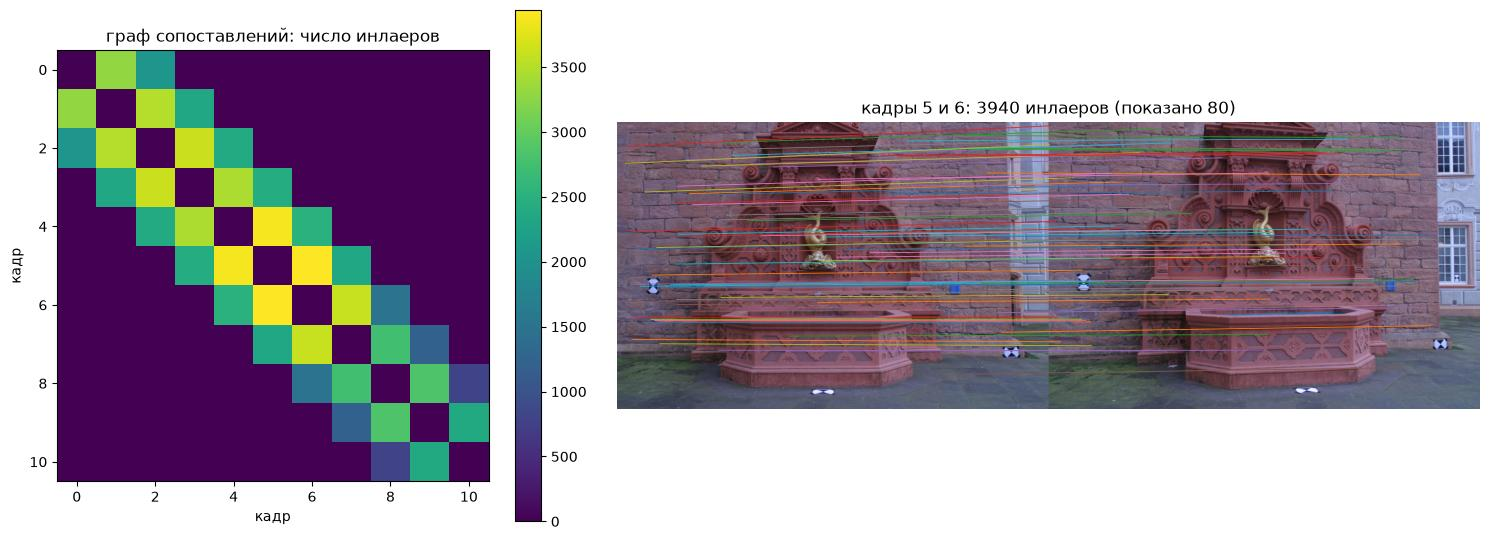

In [6]:
frame_pairs = make_pairs(len(feats), window=2)
matches = {}
for i, j in frame_pairs:
    pair_matches = match_pair(feats[i], feats[j], K)
    if pair_matches is not None:
        matches[(i, j)] = pair_matches
print(f"пар проверено: {len(frame_pairs)}, сопоставлено: {len(matches)}")

# граф сопоставлений: число инлаеров для каждой пары кадров
n_frames = len(feats)
match_graph = np.zeros((n_frames, n_frames))
for (i, j), pair_matches in matches.items():
    match_graph[i, j] = match_graph[j, i] = len(pair_matches)

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw=dict(width_ratios=[1, 1.6]))
im = ax[0].imshow(match_graph, cmap="viridis"); plt.colorbar(im, ax=ax[0])
ax[0].set_title("граф сопоставлений: число инлаеров"); ax[0].set_xlabel("кадр"); ax[0].set_ylabel("кадр")

# пара с наибольшим числом соответствий: линии между сопоставленными точками
i, j = max(matches, key=lambda pair: len(matches[pair]))
pts_i = feats[i]["pts"][matches[(i, j)][:, 0]]
pts_j = feats[j]["pts"][matches[(i, j)][:, 1]]
width_i = scene_frames[i].shape[1]
ax[1].imshow(np.hstack([scene_frames[i], scene_frames[j]]))
for k in np.random.default_rng(0).choice(len(pts_i), min(80, len(pts_i)), replace=False):
    ax[1].plot([pts_i[k, 0], pts_j[k, 0] + width_i], [pts_i[k, 1], pts_j[k, 1]], lw=0.6)
ax[1].set_title(f"кадры {i} и {j}: {len(pts_i)} инлаеров (показано 80)"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## Состояние реконструкции: позы, точки, треки

Всё, что реконструкция знает на текущем шаге, хранится в объекте `rec = Reconstruction(feats, matches, K)`.
Он растёт по ходу работы: инициализация, PnP и триангуляция добавляют позы и точки, BA их уточняет, фильтрация удаляет выбросы.

**Соглашение о позах.** `poses[i] = (R, t)` переводит мировую точку в систему камеры $i$: $\mathbf{x}_c = R\,\mathbf{X} + \mathbf{t}$
(как у `cv2.solvePnP` и `cv2.projectPoints`). Центр камеры $\mathbf{C} = -R^T \mathbf{t}$.
Мировая система координат совпадает с первой камерой начальной пары.

**Трек** — одна 3D-точка и все её наблюдения, то есть особые точки разных кадров, которые на неё смотрят.
Треки собираются из попарных `matches` по мере регистрации кадров. Правила: одна особая точка входит не больше чем в один трек,
и у трека не больше одного наблюдения в кадре — за этим следят `add_point` и `add_observation`.

| поле `rec` | что хранит |
|---|---|
| `poses[i]` | `(R, t)` — поза зарегистрированного кадра $i$ |
| `points[pid]["X"]` | `(3,)` — координаты 3D-точки с номером `pid` |
| `points[pid]["obs"]` | `{кадр: индекс особой точки}` — трек: где точка наблюдается |
| `points[pid]["color"]` | `(3,)` — средний цвет точки по наблюдениям |
| `kp2pt[i][kp]` | обратная ссылка: номер 3D-точки для особой точки `kp` кадра $i$ (или −1) |

Методы:
* `registered()` — номера зарегистрированных кадров; `pair_matches(i, j)` — соответствия пары в любом порядке кадров;
* `add_point`, `add_observation`, `remove_point`, `remove_observation` — изменение треков с соблюдением правил выше;
* `reprojection_error`, `errors()`, `stats()` — ошибки репроекции одного наблюдения, всех наблюдений и сводка.

Ниже сначала вспомогательная геометрия, которой пользуются все следующие этапы: проекция, DLT-триангуляция, угол триангуляции.

In [7]:
# вспомогательная геометрия

def camera_center(R, t):
    """Центр камеры в мировой системе: C = -Rᵀt."""
    return -R.T @ t


def project(K, R, t, X):
    """Проекция точек X (N, 3). Возвращает (uv (N, 2), глубина (N,))."""
    X_cam = X @ R.T + t
    uv_hom = X_cam @ K.T
    return uv_hom[:, :2] / uv_hom[:, 2:3], X_cam[:, 2]


def triangulate(K, pose_a, pose_b, xa, xb):
    """DLT-триангуляция по двум кадрам: xa, xb — (N, 2) пиксели без дисторсии. Возвращает X (N, 3)."""
    P_a, P_b = K @ np.column_stack(pose_a), K @ np.column_stack(pose_b)
    X_hom = cv2.triangulatePoints(P_a, P_b, np.asarray(xa, float).T, np.asarray(xb, float).T)
    return (X_hom[:3] / X_hom[3]).T


def triangulation_angle(Ca, Cb, X):
    """Угол (в градусах) между лучами из центров Ca и Cb в точки X (N, 3)."""
    ray_a, ray_b = X - Ca, X - Cb
    cos = np.sum(ray_a * ray_b, axis=1) / (np.linalg.norm(ray_a, axis=1) * np.linalg.norm(ray_b, axis=1) + 1e-12)
    return np.degrees(np.arccos(np.clip(cos, -1, 1)))

In [8]:
class Reconstruction:
    """Позы зарегистрированных кадров, 3D-точки и их треки."""

    def __init__(self, feats, matches, K):
        self.feats, self.matches, self.K = feats, matches, K
        self.poses = {}                                       # кадр → (R, t)
        self.points = {}                                      # pid → {"X", "color", "obs": {кадр: kp}}
        self.kp2pt = [np.full(len(f["pts"]), -1) for f in feats]
        self._next_pid = 0

    def registered(self):
        return sorted(self.poses)

    def pair_matches(self, i, j):
        """Соответствия кадров i и j: (kp_i, kp_j) — массивы индексов особых точек (пустые, если пары нет)."""
        if (i, j) in self.matches:
            return self.matches[(i, j)][:, 0], self.matches[(i, j)][:, 1]
        if (j, i) in self.matches:
            return self.matches[(j, i)][:, 1], self.matches[(j, i)][:, 0]
        return np.empty(0, int), np.empty(0, int)

    # --- изменение треков ---

    def add_point(self, X, obs):
        """Новая 3D-точка с наблюдениями obs = {кадр: kp}. Уже занятые особые точки пропускаются. Возвращает pid или None."""
        obs = {i: int(kp) for i, kp in obs.items() if self.kp2pt[i][kp] < 0}
        if len(obs) < 2:
            return None
        pid = self._next_pid
        self._next_pid += 1
        color = np.mean([self.feats[i]["colors"][kp] for i, kp in obs.items()], axis=0)
        self.points[pid] = {"X": np.asarray(X, float), "color": color, "obs": obs}
        for i, kp in obs.items():
            self.kp2pt[i][kp] = pid
        return pid

    def add_observation(self, pid, i, kp):
        """Продлить трек pid наблюдением (кадр i, особая точка kp). False, если нельзя."""
        if self.kp2pt[i][kp] >= 0 or i in self.points[pid]["obs"]:
            return False
        self.points[pid]["obs"][i] = int(kp)
        self.kp2pt[i][kp] = pid
        return True

    def remove_point(self, pid):
        for i, kp in self.points.pop(pid)["obs"].items():
            self.kp2pt[i][kp] = -1

    def remove_observation(self, pid, i):
        """Удалить наблюдение точки pid в кадре i; точка, у которой осталось меньше двух наблюдений, удаляется."""
        kp = self.points[pid]["obs"].pop(i)
        self.kp2pt[i][kp] = -1
        if len(self.points[pid]["obs"]) < 2:
            self.remove_point(pid)

    # --- ошибки репроекции ---

    def reprojection_error(self, pid, i, kp):
        """Ошибка (px) проекции точки pid в кадр i относительно особой точки kp; inf, если точка за камерой."""
        uv, depth = project(self.K, *self.poses[i], self.points[pid]["X"][None])
        return np.linalg.norm(uv[0] - self.feats[i]["pts"][kp]) if depth[0] > 0 else np.inf

    def observation_arrays(self):
        """Все наблюдения: (кадр, pid, xy) — массивы длины числа наблюдений."""
        frames, pids, xy = [], [], []
        for pid, point in self.points.items():
            for i, kp in point["obs"].items():
                frames.append(i); pids.append(pid); xy.append(self.feats[i]["pts"][kp])
        return np.array(frames, int), np.array(pids, int), np.array(xy, float).reshape(-1, 2)

    def errors(self):
        """Ошибки репроекции всех наблюдений: (кадр, pid, err). Для точки за камерой err = inf."""
        frames, pids, xy = self.observation_arrays()
        X = np.array([self.points[pid]["X"] for pid in pids]).reshape(-1, 3)
        err = np.empty(len(pids))
        for i in np.unique(frames):
            in_frame = frames == i
            uv, depth = project(self.K, *self.poses[i], X[in_frame])
            err[in_frame] = np.where(depth > 0, np.linalg.norm(uv - xy[in_frame], axis=1), np.inf)
        return frames, pids, err

    def stats(self):
        _, _, err = self.errors()
        track_lengths = [len(point["obs"]) for point in self.points.values()]
        return (f"кадров: {len(self.poses)}/{len(self.feats)}, точек: {len(self.points)}, "
                f"средняя длина трека: {np.mean(track_lengths):.2f}, ошибка репроекции: средняя {np.mean(err):.3f} px, "
                f"медианная {np.median(err):.3f} px")

## Инициализация по паре кадров

Реконструкция стартует с двух кадров: по их соответствиям оцениваем $E$ → $(R, \mathbf{t})$ → триангулируем точки.
Первая камера задаёт мировую систему координат, $(I, \mathbf{0})$, а длина базы $\|\mathbf{t}\| = 1$ — масштаб всей реконструкции.

**Какая пара хорошая.** От неё зависит вся реконструкция:
* **много соответствий** — надёжная оценка $E$;
* **широкая база** — большой угол триангуляции. При почти нулевой базе $E$ плохо обусловлена, а глубина точек определяется
  с огромной ошибкой. Критерий — **медианный угол триангуляции** не меньше `min_angle`;
* **хорошая связность с остальными кадрами.** Иначе после инициализации ни у одного кадра не наберётся 2D–3D соответствий
  для PnP, и реконструкция «застрянет» на изолированной паре.

##### **Функции:** 

(`rec` — объект `Reconstruction`; `i`, `j` — номера кадров;
`X` $(N, 3)$ — триангулированные точки; `kp_i`, `kp_j` — индексы особых точек кадров $i$ и $j$)

* `relative_pose(rec, i, j)` — $E$ по соответствиям пары и `cv2.recoverPose`: из четырёх решений $(R, \mathbf{t})$
  выбирается то, при котором точки оказываются перед обеими камерами.

* `check_points(rec, X, i, kp_i, j, kp_j)` — отбор надёжных триангулированных точек: точка **перед обеими камерами**,
  **ошибка репроекции** в обоих кадрах меньше `MAX_REPROJ`, **угол триангуляции** не меньше `MIN_TRI_ANGLE`.
  Используется и дальше — при триангуляции точек с новых кадров.

* `choose_initial_pair(rec, min_angle=4.0, top=20)` — берёт `top` пар кадров с наибольшим числом соответствий и упорядочивает их
  по связности с остальными кадрами, $\min(\text{conn}_i, \text{conn}_j) - |\text{matches}_{ij}|$, где $\text{conn}_i$ — суммарное
  число соответствий кадра $i$ со всеми кадрами.

* `initialize(rec, i, j)` — позы $(I, \mathbf{0})$ для кадра $i$ и $(R, \mathbf{t})$ для кадра $j$, триангуляция соответствий,
  отбор через `check_points` и добавление точек через `rec.add_point`.

**Результат:** в `rec.poses` — позы двух кадров, в `rec.points` — первые 3D-точки с треками длины 2.

In [9]:
MAX_REPROJ = 4.0          # px — допустимая ошибка репроекции
MIN_TRI_ANGLE = 1.5       # градусы — минимальный угол триангуляции


def check_points(rec, X, i, kp_i, j, kp_j):
    """Маска надёжных триангулированных точек.

    X — (N, 3) точки, триангулированные по кадрам i и j; kp_i, kp_j — (N,) индексы особых точек этих кадров.
    Возвращает булеву маску (N,): точка перед обеими камерами, мала ошибка репроекции и достаточен угол триангуляции.
    """
    valid = np.ones(len(X), bool)
    for frame, kp in ((i, kp_i), (j, kp_j)):
        uv, depth = project(rec.K, *rec.poses[frame], X)
        reproj_error = np.linalg.norm(uv - rec.feats[frame]["pts"][kp], axis=1)
        valid &= (depth > 0) & (reproj_error < MAX_REPROJ)
    angle = triangulation_angle(camera_center(*rec.poses[i]), camera_center(*rec.poses[j]), X)
    return valid & (angle >= MIN_TRI_ANGLE)


def relative_pose(rec, i, j):
    """Относительная поза пары кадров по матрице E.

    Возвращает (R, t, kp_i, kp_j): R (3, 3) и t (3,), |t| = 1 — поза кадра j относительно кадра i;
    kp_i, kp_j — (M,) индексы особых точек соответствий, прошедших проверку хиральности.
    """
    kp_i, kp_j = rec.pair_matches(i, j)
    pts_i, pts_j = rec.feats[i]["pts"][kp_i], rec.feats[j]["pts"][kp_j]
    E, inlier_mask = cv2.findEssentialMat(pts_i, pts_j, rec.K, method=cv2.USAC_MAGSAC, prob=0.999, threshold=1.0)
    _, R, t, inlier_mask = cv2.recoverPose(E[:3], pts_i, pts_j, rec.K, mask=inlier_mask)
    inliers = inlier_mask.ravel() > 0
    return R, t.ravel(), kp_i[inliers], kp_j[inliers]

In [10]:
def choose_initial_pair(rec, min_angle=4.0, top=20):
    """Пара кадров для инициализации: много соответствий, хорошая связность и широкая база.

    min_angle — минимальный медианный угол триангуляции, градусы; 
    top — сколько пар с наибольшим числом соответствий рассматривать.
    Возвращает (i, j) — номера кадров.
    """
    # связность кадра — суммарное число его соответствий со всеми кадрами
    connectivity = np.zeros(len(rec.feats))
    for (a, b), pair_matches in rec.matches.items():
        connectivity[a] += len(pair_matches)
        connectivity[b] += len(pair_matches)

    # кандидаты — пары с наибольшим числом соответствий, сначала лучше связанные с ОСТАЛЬНЫМИ кадрами
    candidates = sorted(rec.matches, key=lambda pair: -len(rec.matches[pair]))[:top]
    candidates.sort(key=lambda pair: -(min(connectivity[pair[0]], connectivity[pair[1]]) - len(rec.matches[pair])))

    best_pair, best_angle = None, -1
    for i, j in candidates:
        R, t, kp_i, kp_j = relative_pose(rec, i, j)
        X = triangulate(rec.K, (np.eye(3), np.zeros(3)), (R, t), rec.feats[i]["pts"][kp_i], rec.feats[j]["pts"][kp_j])
        angle = np.median(triangulation_angle(np.zeros(3), camera_center(R, t), X))
        print(f"  пара ({i}, {j}): {len(kp_i)} соответствий, медианный угол {angle:.1f}°")
        if angle >= min_angle:
            return i, j
        if angle > best_angle:
            best_pair, best_angle = (i, j), angle
    print("нет пары с достаточным углом — берём пару с наибольшим углом")
    return best_pair


def initialize(rec, i, j):
    """Позы кадров i, j и первые 3D-точки по их соответствиям.

    Ничего не возвращает: заполняет rec.poses[i] = (I, 0), rec.poses[j] = (R, t) и добавляет точки в rec.points.
    """
    R, t, kp_i, kp_j = relative_pose(rec, i, j)
    rec.poses[i] = (np.eye(3), np.zeros(3))
    rec.poses[j] = (R, t)
    X = triangulate(rec.K, rec.poses[i], rec.poses[j], rec.feats[i]["pts"][kp_i], rec.feats[j]["pts"][kp_j])
    valid = check_points(rec, X, i, kp_i, j, kp_j)
    for X_point, kp_a, kp_b in zip(X[valid], kp_i[valid], kp_j[valid]):
        rec.add_point(X_point, {i: kp_a, j: kp_b})

Запускаем инициализацию на отдельном объекте `rec_init` и смотрим
несколько первых 3D-точек: где они видны на обоих кадрах, их координаты и угол триангуляции.

  пара (3, 5): 2443 соответствий, медианный угол 22.4°
начальная пара: кадры 3 (0003.png) и 5 (0005.png); поворот между ними 21.7°, точек: 2443

 №     пиксель в кадре 3     пиксель в кадре 5                     X, Y, Z  угол, °
 0       [2754.1 1031.7]       [2769.6  943.1]         [0.964 0.019 2.157]    21.8
 1       [2412.9  244.7]       [2483.3  201.2]      [ 0.745 -0.635  2.304]    21.7
 2       [2341.5 1276.8]       [2424.8 1163.4]         [0.666 0.219 2.239]    23.2
 3       [1912.8  409.1]       [2013.8  305.8]      [ 0.346 -0.527  2.438]    22.7
 4       [2541.7  151. ]       [2597.7  127.9]      [ 0.84  -0.703  2.27 ]    21.2
 5       [2478.5 1455.1]       [2540.9 1324.5]         [0.763 0.356 2.197]    22.8
 6       [1963.7 1667.9]       [2187.5 1546.3]         [0.338 0.504 2.107]    25.8
 7         [2424.  458.]       [2494.2  403.2]      [ 0.747 -0.453  2.282]    22.1
 8       [2427.7  567.4]       [2495.5  505.6]      [ 0.749 -0.362  2.277]    22.3
 9       [ 656.5 1701.1]

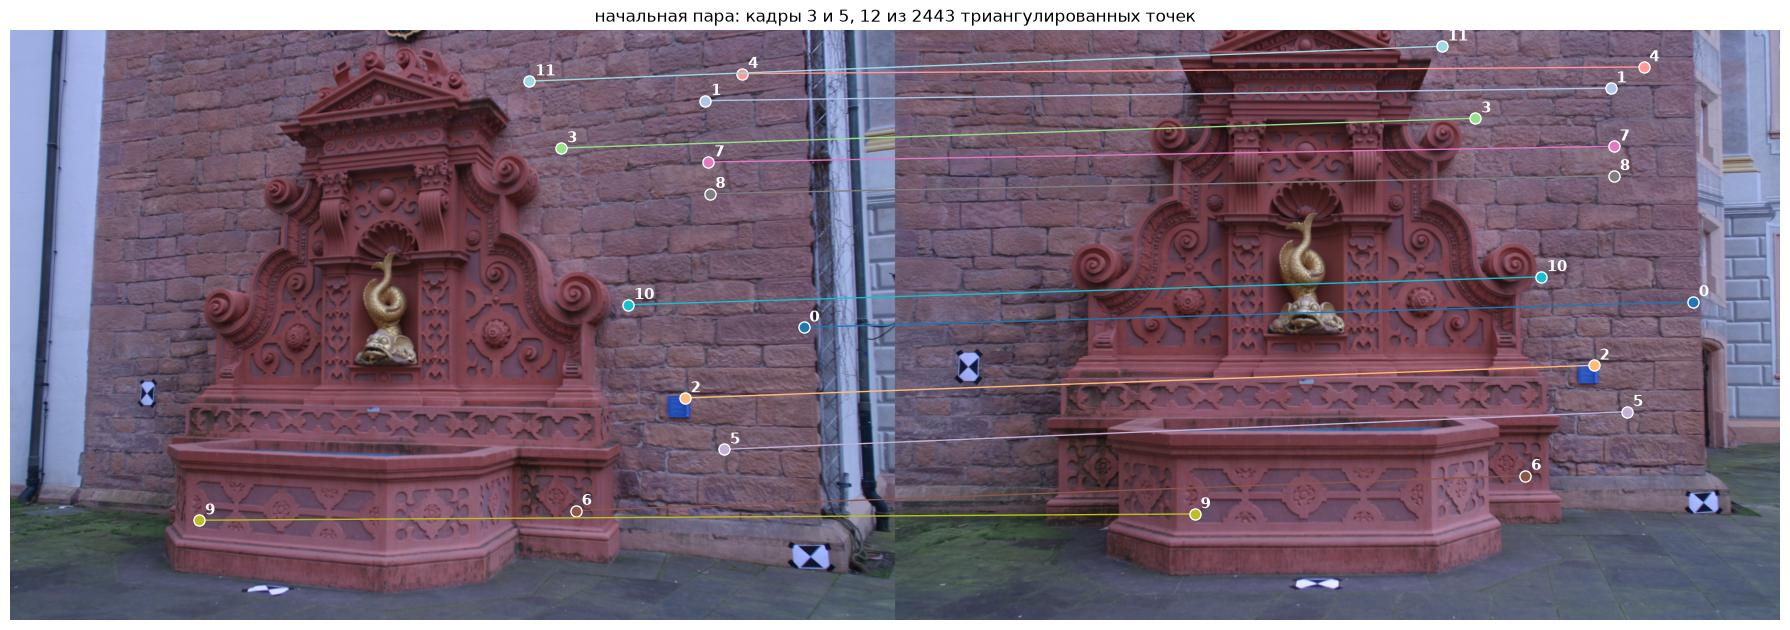

In [11]:
rec_init = Reconstruction(feats, matches, K)

i0, j0 = choose_initial_pair(rec_init)

initialize(rec_init, i0, j0)

R0, t0 = rec_init.poses[j0]
print(f"начальная пара: кадры {i0} ({scene_names[i0]}) и {j0} ({scene_names[j0]}); "
      f"поворот между ними {np.degrees(np.linalg.norm(cv2.Rodrigues(R0)[0])):.1f}°, точек: {len(rec_init.points)}")

N_SHOW = 12
shown_pids = np.random.default_rng(0).choice(list(rec_init.points), N_SHOW, replace=False)
colors = plt.cm.tab20(np.linspace(0, 1, N_SHOW))
center_i, center_j = camera_center(*rec_init.poses[i0]), camera_center(*rec_init.poses[j0])
width_i = scene_frames[i0].shape[1]

fig, ax = plt.subplots(figsize=(18, 6.5))
ax.imshow(np.hstack([scene_frames[i0], scene_frames[j0]]))
print(f"\n{'№':>2}  {'пиксель в кадре ' + str(i0):>20}  {'пиксель в кадре ' + str(j0):>20}  {'X, Y, Z':>26}  угол, °")
for n, (pid, color) in enumerate(zip(shown_pids, colors)):
    point = rec_init.points[pid]
    uv_i = feats[i0]["pts"][point["obs"][i0]]
    uv_j = feats[j0]["pts"][point["obs"][j0]]
    angle = triangulation_angle(center_i, center_j, point["X"][None])[0]
    print(f"{n:>2}  {str(uv_i.round(1)):>20}  {str(uv_j.round(1)):>20}  {str(point['X'].round(3)):>26}  {angle:6.1f}")

    ax.plot([uv_i[0], uv_j[0] + width_i], [uv_i[1], uv_j[1]], color=color, lw=1)
    for u, v in (uv_i, (uv_j[0] + width_i, uv_j[1])):
        ax.plot(u, v, "o", color=color, ms=8, mec="white")
        ax.text(u + 20, v - 20, str(n), color="white", fontsize=11, weight="bold")
ax.set_title(f"начальная пара: кадры {i0} и {j0}, {N_SHOW} из {len(rec_init.points)} триангулированных точек")
ax.axis("off"); plt.tight_layout(); plt.show()

## Регистрация новых кадров

После инициализации реконструкция растёт по одному кадру. Следующим берётся незарегистрированный кадр $j$, у которого больше всего особых точек, сопоставленных с триангулированными точками зарегистрированных кадров – с точками в треке (в `rec.points`).

Особые точки кадра $j$ делятся на группы:
* **Группа A** — особые точки кадра $j$, сопоставленные с особыми точками зарегистрированных кадров, которые уже входят в треки, то есть для которых уже известна 3D-точка.

* **группа B** — особые точки кадра $j$, сопоставленные с особыми точками зарегистрированных кадров, которые не входят ни в один трек (у них нет 3D-точки).

* **Группа C** — особые точки кадра $j$, не сопоставленые ни с одним зарегистрированным кадром. Сейчас с ними ничего не происходит. Когда позже
зарегистрируют кадр, с которым такая точка сопоставлена, она попадёт в группу B уже для той пары и будет триангулирована.

### Шаг 1. Поза кадра по точкам группы A

Особая точка кадра $j$ сопоставлена с особой точкой зарегистрированного кадра $i$,
а та уже входит в трек → известно, какой 3D-точке $\mathbf{X}_k$ соответствует пиксель $\mathbf{x}_k$ кадра $j$ (`find_2d3d`).

**PnP (Perspective-n-Point).** Известны точки $\mathbf{X}_k$, их пиксели $\mathbf{x}_k$ и $K$; ищем позу, при которой
проекции точек попадают в эти пиксели:

$$\min_{R,\,\mathbf{t}} \sum_k \big\|\mathbf{x}_k - \pi(K, R, \mathbf{t}, \mathbf{X}_k)\big\|^2$$

1. `cv2.solvePnPRansac` — RANSAC многократно решает PnP по небольшой выборке соответствий (SQPnP) и считает, у скольких
   соответствий ошибка репроекции меньше `MAX_REPROJ`. Лучшая поза — начальное приближение, а соответствия делятся
   на **инлаеры** и **выбросы**;
2. `cv2.solvePnPRefineLM` — уточнение позы по инлаерам (Левенберг–Марквардт): тот же BA, но меняется только одна камера,
   а точки фиксированы;
3. если инлаеров меньше `MIN_PNP_INLIERS`, кадр не регистрируется — основной цикл попробует его позже.

**Что происходит с точками группы A:** инлаер PnP добавляется в трек как ещё одно наблюдение этой 3D-точки (трек удлиняется),
выброс — не добавляется (скорее всего, это ложное сопоставление).

### Шаг 2. Триангуляция точек (поза $j$ уже известна)

Шаг 2 перебирает все соответствия кадра $j$ с каждым зарегистрированным кадром $i$ и обрабатывает те, где хотя бы у одной из двух особых точек нет 3D-точки.


| у точки кадра $j$ | у точки кадра $i$ | что делаем |
|---|---|---|
| нет 3D | нет 3D | **B** — триангулируем новую точку $\mathbf{X}$ по кадрам $j$ и $i$. **Обе особые точки добавляются** в новый трек длины 2, если `check_points` пройдена: $\mathbf{X}$ перед обеими камерами, ошибка репроекции в обоих кадрах < `MAX_REPROJ`, угол триангуляции ≥ `MIN_TRI_ANGLE`. Иначе обе остаются свободными: точка кадра $j$ получит ещё попытку с другим кадром $i$ |
| есть 3D (инлаер PnP или триангулирована с более ранним $i$) | нет 3D | **точка кадра $i$ добавляется** в трек точки кадра $j$, если проекция её 3D-точки в кадр $i$ лежит перед камерой с ошибкой < `MAX_REPROJ` и у трека ещё нет наблюдения в кадре $i$. Иначе остаётся свободной |
| нет 3D (выброс PnP) | есть 3D | второй шанс: **точка кадра $j$ добавляется** в трек точки кадра $i$, если проекция 3D-точки в кадр $j$ (с уточнённой позой) лежит перед камерой с ошибкой < `MAX_REPROJ` и у трека ещё нет наблюдения в кадре $j$. Иначе остаётся свободной |
| есть 3D | есть 3D | ничего не добавляем: обе точки уже в треках. Если треки разные, они **не объединяются** |








##### **Функции** (`rec` — объект `Reconstruction`, `j` — номер нового кадра):
* `find_2d3d(rec, j)` — 2D–3D соответствия кадра $j$ по всем зарегистрированным кадрам.
  * **возвращает** `(kp_j, pids)`: `kp_j` $(N,)$ — индексы особых точек кадра $j$,
    `pids` $(N,)$ — номера соответствующих 3D-точек в `rec.points`.
* `register_image(rec, j)` — поза кадра $j$ по PnP; инлаеры добавляются в треки как наблюдения.
  * **возвращает** `True`, если кадр зарегистрирован (инлаеров PnP не меньше `MIN_PNP_INLIERS`), иначе `False`.
    При успехе заполняет `rec.poses[j]`.
* `triangulate_new_points(rec, j)` — новые 3D-точки и продление треков по соответствиям кадра $j$ с зарегистрированными кадрами.
  * **возвращает** `(n_new, n_extended)` — число новых точек и продлённых треков; изменяет `rec.points` и `rec.kp2pt`.

**Результат:** в `rec.poses` добавляется поза кадра $j$, в `rec.points` — новые точки, а существующие треки становятся длиннее.

In [12]:
MIN_PNP_INLIERS = 30


def find_2d3d(rec, j):
    """2D–3D соответствия незарегистрированного кадра j.

    Возвращает (kp_j, pids) — массивы (N,): индексы особых точек кадра j без повторов и номера их 3D-точек.
    """
    kp_parts, pid_parts = [], []
    for i in rec.poses:
        kp_j, kp_i = rec.pair_matches(j, i)
        pid_i = rec.kp2pt[i][kp_i]
        has_point = pid_i >= 0
        kp_parts.append(kp_j[has_point]); pid_parts.append(pid_i[has_point])
    if not kp_parts:
        return np.empty(0, int), np.empty(0, int)
    kp_j, pids = np.concatenate(kp_parts), np.concatenate(pid_parts)
    # особая точка кадра j может быть сопоставлена с несколькими кадрами — оставляем одно соответствие
    kp_j, first_occurrence = np.unique(kp_j, return_index=True)
    return kp_j, pids[first_occurrence]


def register_image(rec, j):
    """Поза кадра j по PnP; инлаеры добавляются в треки. Возвращает True, если кадр зарегистрирован."""
    kp_j, pids = find_2d3d(rec, j)
    if len(kp_j) < MIN_PNP_INLIERS:
        return False
    X = np.array([rec.points[pid]["X"] for pid in pids])
    pts_j = rec.feats[j]["pts"][kp_j]

    # 1. PnP + RANSAC: начальная поза и инлаеры
    found, rvec, tvec, inliers = cv2.solvePnPRansac(X, pts_j, rec.K, None, iterationsCount=2000,
                                                    reprojectionError=MAX_REPROJ, confidence=0.999,
                                                    flags=cv2.SOLVEPNP_SQPNP)
    if not found or inliers is None or len(inliers) < MIN_PNP_INLIERS:
        return False
    inliers = inliers.ravel()

    # 2. нелинейное уточнение позы по инлаерам
    rvec, tvec = cv2.solvePnPRefineLM(X[inliers], pts_j[inliers], rec.K, None, rvec, tvec)
    rec.poses[j] = (cv2.Rodrigues(rvec)[0], tvec.ravel())

    # 3. инлаеры PnP — новые наблюдения существующих треков
    for k in inliers:
        rec.add_observation(pids[k], j, kp_j[k])
    return True


def triangulate_new_points(rec, j):
    """Новые точки и продление треков по соответствиям кадра j с зарегистрированными кадрами.

    Возвращает (n_new, n_extended) — число новых 3D-точек и продлённых треков.
    """
    n_new = n_extended = 0
    for i in rec.registered():
        if i == j:
            continue
        kp_j, kp_i = rec.pair_matches(j, i)
        if len(kp_j) == 0:
            continue
        pid_j, pid_i = rec.kp2pt[j][kp_j], rec.kp2pt[i][kp_i]

        # 1. продление треков: 3D-точка есть только у одной из двух особых точек — вторая становится её наблюдением
        only_in_i = (pid_j < 0) & (pid_i >= 0)
        only_in_j = (pid_i < 0) & (pid_j >= 0)
        extensions = ([(j, kp, pid) for kp, pid in zip(kp_j[only_in_i], pid_i[only_in_i])] +
                      [(i, kp, pid) for kp, pid in zip(kp_i[only_in_j], pid_j[only_in_j])])
        for frame, kp, pid in extensions:
            if (pid in rec.points and rec.reprojection_error(pid, frame, kp) < MAX_REPROJ
                    and rec.add_observation(pid, frame, kp)):
                n_extended += 1

        # 2. новые точки: ни у одной из двух особых точек нет 3D-точки
        free = (rec.kp2pt[j][kp_j] < 0) & (rec.kp2pt[i][kp_i] < 0)
        if not free.any():
            continue
        kp_j_free, kp_i_free = kp_j[free], kp_i[free]
        X = triangulate(rec.K, rec.poses[j], rec.poses[i], rec.feats[j]["pts"][kp_j_free], rec.feats[i]["pts"][kp_i_free])
        valid = check_points(rec, X, j, kp_j_free, i, kp_i_free)
        for X_point, kp_a, kp_b in zip(X[valid], kp_j_free[valid], kp_i_free[valid]):
            n_new += rec.add_point(X_point, {j: kp_a, i: kp_b}) is not None
    return n_new, n_extended

Регистрируем один кадр на копии `rec_init` — так же, как это делает основной цикл. На кадре видно, какие 2D–3D соответствия
PnP принял (инлаеры) и отбросил (выбросы) и какие точки триангулированы заново. Справа — вид сверху: камеры и точки до и после.

2D–3D соответствий у незарегистрированных кадров: {0: 0, 1: 1151, 2: 1667, 4: 2043, 6: 1612, 7: 990, 8: 0, 9: 0, 10: 0}
кадр 4 (0004.png): 2D–3D 2043, инлаеров PnP 2025, центр камеры [-0.479  0.004  0.109]
новых точек 3000, продлено треков 340; всего точек 2443 → 5443


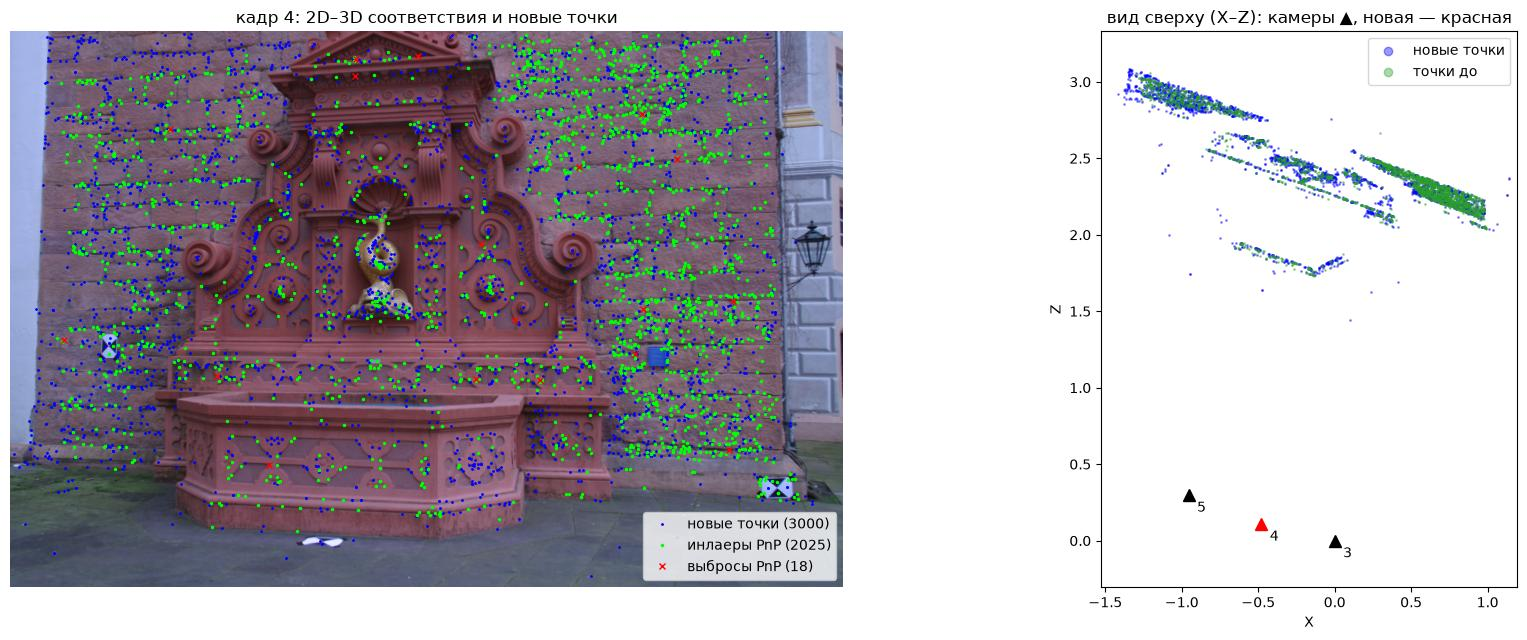

In [13]:
import copy

rec_step = copy.deepcopy(rec_init)

# следующий кадр — с наибольшим числом 2D–3D соответствий
n_2d3d = {j: len(find_2d3d(rec_step, j)[0]) for j in range(len(feats)) if j not in rec_step.poses}
j_new = max(n_2d3d, key=n_2d3d.get)
print("2D–3D соответствий у незарегистрированных кадров:", n_2d3d)

kp_j, pids = find_2d3d(rec_step, j_new)
pids_before = set(rec_step.points)
assert register_image(rec_step, j_new), f"кадр {j_new} не зарегистрирован"
is_inlier = rec_step.kp2pt[j_new][kp_j] == pids
n_new, n_extended = triangulate_new_points(rec_step, j_new)
new_pids = [pid for pid in rec_step.points if pid not in pids_before]

R_new, t_new = rec_step.poses[j_new]
print(f"кадр {j_new} ({scene_names[j_new]}): 2D–3D {len(kp_j)}, инлаеров PnP {is_inlier.sum()}, "
      f"центр камеры {camera_center(R_new, t_new).round(3)}")
print(f"новых точек {n_new}, продлено треков {n_extended}; всего точек {len(rec_init.points)} → {len(rec_step.points)}")

fig, ax = plt.subplots(1, 2, figsize=(18, 6.5), gridspec_kw=dict(width_ratios=[1.6, 1]))
pts_j = feats[j_new]["pts"]
new_kp = [rec_step.points[pid]["obs"][j_new] for pid in new_pids]
ax[0].imshow(scene_frames[j_new])
ax[0].plot(*pts_j[new_kp].T, ".", color="blue", ms=2, label=f"новые точки ({len(new_pids)})")
ax[0].plot(*pts_j[kp_j[is_inlier]].T, ".", color="lime", ms=3, label=f"инлаеры PnP ({is_inlier.sum()})")
ax[0].plot(*pts_j[kp_j[~is_inlier]].T, "x", color="red", ms=5, label=f"выбросы PnP ({(~is_inlier).sum()})")
ax[0].set_title(f"кадр {j_new}: 2D–3D соответствия и новые точки"); ax[0].legend(loc="lower right"); ax[0].axis("off")

# вид сверху (X–Z): камера смотрит вдоль Z
X_old = np.array([rec_step.points[pid]["X"] for pid in pids_before if pid in rec_step.points])
X_new = np.array([rec_step.points[pid]["X"] for pid in new_pids])
centers = np.array([camera_center(*rec_step.poses[i]) for i in rec_step.registered()])
ax[1].scatter(X_new[:, 0], X_new[:, 2], s=1, c="blue", alpha=0.4, label="новые точки")
ax[1].scatter(X_old[:, 0], X_old[:, 2], s=1, c="tab:green", alpha=0.4, label="точки до")
for i, C in zip(rec_step.registered(), centers):
    ax[1].plot(C[0], C[2], "^", color="red" if i == j_new else "black", ms=9)
    ax[1].annotate(str(i), (C[0], C[2]), textcoords="offset points", xytext=(6, -12))
# границы: 1–99 перцентили точек (редкие далёкие точки не сжимают картинку) плюс все камеры
X_points = np.vstack([X_old, X_new])
low = np.minimum(np.percentile(X_points, 1, axis=0), centers.min(0))
high = np.maximum(np.percentile(X_points, 99, axis=0), centers.max(0))
margin = 0.1 * (high - low)
ax[1].set_xlim(low[0] - margin[0], high[0] + margin[0]); ax[1].set_ylim(low[2] - margin[2], high[2] + margin[2])
ax[1].set_title("вид сверху (X–Z): камеры ▲, новая — красная"); ax[1].set_xlabel("X"); ax[1].set_ylabel("Z")
ax[1].set_aspect("equal"); ax[1].legend(loc="upper right", markerscale=6)
plt.tight_layout(); plt.show()

## Bundle adjustment и фильтрация

 Каждый шаг регистрация новых кадров доверяет неточным данным.  PnP считает 3D-координаты точными, триангуляция — позы. Ошибки одних
   переходят в другие. Каждый новый кадр опирается на предыдущие и ошибки накапливаются. Используются не все наблюдени: точка триангулируется по двум кадрам, хотя потом видна в 5–10. DLT-триангуляция и линейный PnP минимизируют алгебраическую ошибку (ошибку в пикселях, умноженную на глубину), а не ошибку репроекции в пикселях.

Поэтому PnP и триангуляция дают **начальное приближение**, а BA уточняет всё совместно по всем наблюдениям.


$$\min_{\{R_i, \mathbf{t}_i\},\,\{\mathbf{X}_p\}} \sum_{(i,p)} \rho\left(\left\| \pi\!\left(K (R_i \mathbf{X}_p + \mathbf{t}_i)\right) - \mathbf{x}_{ip} \right\|^2\right)$$

* **Известно:** наблюдения $\mathbf{x}_{ip}$ — пиксель точки $p$ в кадре $i$ (из треков, `rec.observation_arrays()`), и $K$.

* **Уточняем:** позы — 6 параметров на камеру (вектор Родрига + сдвиг), и точки — по 3 параметра.
  Начальные значения — текущие позы и точки из PnP и триангуляции.
* **Робастная функция потерь** $\rho$ — Хьюбер с порогом `f_scale = 2` px: квадратичная для малых ошибок и линейная для больших,
  поэтому оставшиеся выбросы меньше тянут решение на себя.
* **Что именно уменьшается.** Минимизируется сумма квадратов ошибок, а в ней главную роль играют большие ошибки.
  Поэтому BA в первую очередь сжимает «хвост» распределения; медианная ошибка при этом может даже немного вырасти.


##### **Фильтрация** после BA удаляет:

Шаг 1. Удаляет плохие наблюдения: проецирует каждую 3D-точку во все кадры, где она наблюдается, и считает ошибку репроекции каждого наблюдения в пикселях. Если точка оказалась за камерой, ошибка равна inf. Все наблюдения с ошибкой больше max_err (4 px) или за камерой удаляются через rec.remove_observation(pid, frame).
Удаляется именно наблюдение, а не вся точка. Если в одном кадре сопоставление ложное, а в остальных четырёх хорошее, точка остаётся, просто с треком на одно наблюдение короче.

Шаг 2. Удаляет точки с малым углом триангуляции
Для каждой оставшейся точки строятся лучи из центров всех камер, которые её наблюдают. Находится наибольший угол между любыми двумя лучами. Берётся именно наибольший угол, потому что для точности хватает хотя бы одной пары камер с хорошей базой.

До BA большая ошибка часто означает неточную позу, а не плохое наблюдение: дрейф ещё не исправлен. Удалив такие наблюдения, мы бы выбросили хорошие данные. После BA ошибка отражает реальную несогласованность. Поэтому порядок такой: BA → фильтрация → снова BA уже без выбросов. В основном цикле финальный этап сделан именно так.


##### **Функции:**
* `rotate(X, rvecs)` — поворот точек, каждой своим вектором Родрига (формула Родрига для массива).
  * **аргументы:** `X` $(M, 3)$ — точки, `rvecs` $(M, 3)$ — векторы Родрига; **возвращает** повёрнутые точки $(M, 3)$.
* `project_ba(X, cam_params, K)` — проекция для BA: у каждого наблюдения своя точка и свои параметры камеры.
  * **аргументы:** `X` $(M, 3)$, `cam_params` $(M, 6)$ = `[rvec, tvec]`; **возвращает** пиксели $(M, 2)$.
* `ba_sparsity(n_cams, n_points, obs_cam, obs_point)` — маска разреженности якобиана.
  * **аргументы:** число свободных камер и точек; `obs_cam`, `obs_point` $(M,)$ — номера камеры и точки каждого наблюдения
    (−1 — фиксированная камера); **возвращает** разреженную матрицу $(2M,\ 6\,n_\text{cams} + 3\,n_\text{points})$.
* `bundle_adjust(rec, max_nfev=30)` — BA по всем зарегистрированным кадрам; `max_nfev` — максимум вычислений невязок.
  * **возвращает** `None`: обновляет `rec.poses` (кроме первого кадра) и `rec.points[pid]["X"]`, печатает ошибки до и после.
* `filter_points(rec, max_err=MAX_REPROJ, min_angle=MIN_TRI_ANGLE)` — фильтрация.
  * **возвращает** `(n_removed_obs, n_removed_points)` — число удалённых наблюдений и точек, удалённых по углу.

**Где вызывается.** В основном цикле BA глобальный: после инициализации, после каждых `BA_EVERY` добавленных кадров
и в конце. Локального BA (новый кадр + соседи) у нас нет — для десятков кадров глобальный достаточно быстр.

In [14]:
def rotate(X, rvecs):
    """Поворот точек X (M, 3) векторами Родрига rvecs (M, 3): X cosθ + (k × X) sinθ + k (k·X)(1 − cosθ)."""
    theta = np.linalg.norm(rvecs, axis=1, keepdims=True)
    with np.errstate(invalid="ignore", divide="ignore"):
        axis = np.nan_to_num(rvecs / theta)                   # единичная ось; при θ = 0 — нулевой вектор
    cos, sin = np.cos(theta), np.sin(theta)
    return cos * X + sin * np.cross(axis, X) + np.sum(X * axis, axis=1, keepdims=True) * (1 - cos) * axis


def project_ba(X, cam_params, K):
    """Проекция точек X (M, 3) камерами cam_params (M, 6) = [rvec, tvec] — по одной на наблюдение. Возвращает (M, 2)."""
    X_cam = rotate(X, cam_params[:, :3]) + cam_params[:, 3:]
    uv_hom = X_cam @ K.T
    return uv_hom[:, :2] / uv_hom[:, 2:3]


def ba_sparsity(n_cams, n_points, obs_cam, obs_point):
    """Маска разреженности якобиана BA (2M, 6·n_cams + 3·n_points): 1 там, где невязка зависит от параметра.

    obs_cam (M,) — номер свободной камеры наблюдения (−1 — фиксированная, у неё нет параметров), obs_point (M,) — номер точки.
    """
    n_obs = len(obs_cam)
    has_free_cam = obs_cam >= 0
    rows, cols = [], []
    for coord in range(2):                                    # строки u и v каждого наблюдения
        row = 2 * np.arange(n_obs) + coord
        for q in range(3):                                    # 3 координаты точки
            rows.append(row); cols.append(6 * n_cams + 3 * obs_point + q)
        for q in range(6):                                    # 6 параметров камеры
            rows.append(row[has_free_cam]); cols.append(6 * obs_cam[has_free_cam] + q)
    rows, cols = np.concatenate(rows), np.concatenate(cols)
    return coo_matrix((np.ones(len(rows)), (rows, cols)), shape=(2 * n_obs, 6 * n_cams + 3 * n_points))


def bundle_adjust(rec, max_nfev=30, verbose=True):
    """Совместное уточнение поз всех зарегистрированных кадров (кроме первого) и всех 3D-точек.

    Ничего не возвращает: обновляет rec.poses и rec.points[pid]["X"].
    """
    frames = rec.registered()
    fixed_frame, free_frames = frames[0], frames[1:]          # первая камера фиксирована — она задаёт систему координат
    pids = list(rec.points)
    n_cams, n_points = len(free_frames), len(pids)

    # для каждого наблюдения — номер свободной камеры (−1 — фиксированная) и номер точки
    obs_frame, obs_pid, obs_xy = rec.observation_arrays()
    cam_index = {frame: k for k, frame in enumerate(free_frames)}
    point_index = {pid: k for k, pid in enumerate(pids)}
    obs_cam = np.array([cam_index.get(frame, -1) for frame in obs_frame])
    obs_point = np.array([point_index[pid] for pid in obs_pid])

    # вектор параметров: [rvec, tvec] свободных камер, затем координаты точек
    def pose_params(frame):
        R, t = rec.poses[frame]
        return np.r_[cv2.Rodrigues(R)[0].ravel(), t]

    fixed_params = pose_params(fixed_frame)
    x0 = np.r_[np.ravel([pose_params(frame) for frame in free_frames]), np.ravel([rec.points[pid]["X"] for pid in pids])]

    def residuals(x):
        cam_params = np.vstack([x[:6 * n_cams].reshape(n_cams, 6), fixed_params])   # индекс −1 → фиксированная камера
        points = x[6 * n_cams:].reshape(n_points, 3)
        return (project_ba(points[obs_point], cam_params[obs_cam], rec.K) - obs_xy).ravel()

    err_before = np.linalg.norm(residuals(x0).reshape(-1, 2), axis=1)
    result = least_squares(residuals, x0, jac_sparsity=ba_sparsity(n_cams, n_points, obs_cam, obs_point),
                           x_scale="jac", method="trf", loss="huber", f_scale=2.0, max_nfev=max_nfev)
    err_after = np.linalg.norm(result.fun.reshape(-1, 2), axis=1)

    # результат — обратно в rec
    for k, frame in enumerate(free_frames):
        params = result.x[6 * k: 6 * k + 6]
        rec.poses[frame] = (cv2.Rodrigues(params[:3])[0], params[3:].copy())
    for k, pid in enumerate(pids):
        rec.points[pid]["X"] = result.x[6 * n_cams + 3 * k: 6 * n_cams + 3 * k + 3].copy()

    if verbose:
        print(f"  BA: {len(frames)} кадров, {n_points} точек, {len(obs_cam)} наблюдений; ошибка (средняя / медианная) "
              f"{err_before.mean():.3f} / {np.median(err_before):.3f} → {err_after.mean():.3f} / {np.median(err_after):.3f} px")


def filter_points(rec, max_err=MAX_REPROJ, min_angle=MIN_TRI_ANGLE):
    """Удаляет плохие наблюдения и точки.

    Возвращает (n_removed_obs, n_removed_points) — число удалённых наблюдений и точек, удалённых по углу триангуляции.
    """
    # 1. наблюдения с большой ошибкой репроекции; за камерой err = inf, они тоже попадают сюда
    frames, pids, err = rec.errors()
    is_bad = err > max_err
    n_removed_obs = 0
    for frame, pid in zip(frames[is_bad], pids[is_bad]):
        if pid in rec.points and frame in rec.points[pid]["obs"]:
            rec.remove_observation(pid, frame)
            n_removed_obs += 1

    # 2. точки с малым наибольшим углом между лучами наблюдений
    centers = {i: camera_center(*rec.poses[i]) for i in rec.poses}
    n_removed_points = 0
    for pid in list(rec.points):
        point = rec.points[pid]
        rays = point["X"] - np.array([centers[i] for i in point["obs"]])
        rays /= np.linalg.norm(rays, axis=1, keepdims=True)
        max_angle = np.degrees(np.arccos(np.clip((rays @ rays.T).min(), -1, 1)))   # наибольший угол ↔ наименьший косинус
        if max_angle < min_angle:
            rec.remove_point(pid)
            n_removed_points += 1
    return n_removed_obs, n_removed_points

Берём копию `rec_step` и добавляем ещё несколько кадров **без BA**, как если бы его не было. Затем запускаем BA и фильтрацию
и сравниваем ошибки репроекции: BA сжимает «хвост» больших ошибок (99-й перцентиль), а медиана почти не меняется. Слева — маска разреженности якобиана для нескольких точек: каждое наблюдение (две строки)
зависит только от одной камеры и одной точки.

без BA: кадров: 6/11, точек: 9223, средняя длина трека: 3.20, ошибка репроекции: средняя 0.276 px, медианная 0.131 px


  BA: 6 кадров, 9223 точек, 29503 наблюдений; ошибка (средняя / медианная) 0.276 / 0.131 → 0.214 / 0.149 px
фильтрация: удалено наблюдений 0, точек по углу 0
после BA и фильтрации: кадров: 6/11, точек: 9223, средняя длина трека: 3.20, ошибка репроекции: средняя 0.214 px, медианная 0.149 px


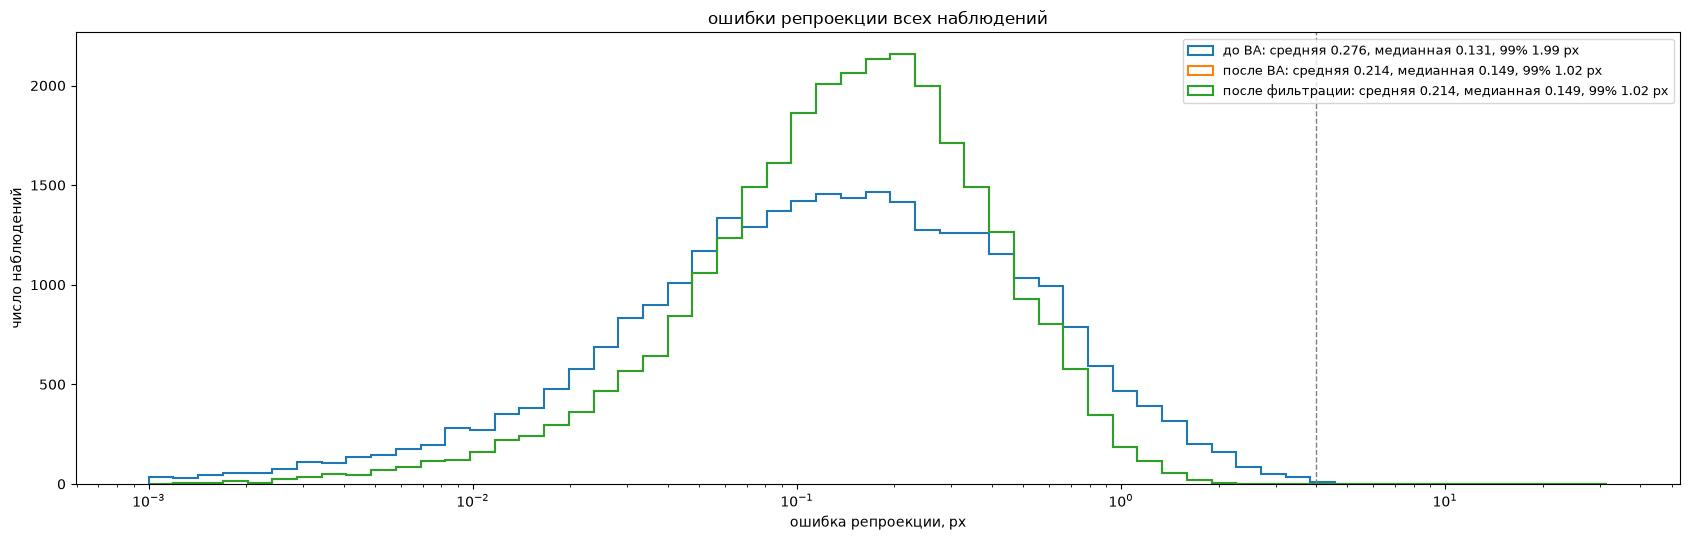

In [15]:
rec_ba = copy.deepcopy(rec_step)
for _ in range(3):
    n_2d3d = {j: len(find_2d3d(rec_ba, j)[0]) for j in range(len(feats)) if j not in rec_ba.poses}
    j_new = max(n_2d3d, key=n_2d3d.get)
    if register_image(rec_ba, j_new):
        triangulate_new_points(rec_ba, j_new)
print("без BA:", rec_ba.stats())

_, _, err_before = rec_ba.errors()
bundle_adjust(rec_ba)
_, _, err_after_ba = rec_ba.errors()
n_removed_obs, n_removed_points = filter_points(rec_ba)
_, _, err_after_filter = rec_ba.errors()
print(f"фильтрация: удалено наблюдений {n_removed_obs}, точек по углу {n_removed_points}")
print("после BA и фильтрации:", rec_ba.stats())

fig, ax = plt.subplots(1, 1, figsize=(17, 5.5), gridspec_kw=dict(width_ratios=[1,]))


bins = np.logspace(-3, 1.5, 60)
for err, label in ((err_before, "до BA"), (err_after_ba, "после BA"), (err_after_filter, "после фильтрации")):
    err = err[np.isfinite(err)]
    ax.hist(err, bins=bins, histtype="step", lw=1.5,
               label=f"{label}: средняя {err.mean():.3f}, медианная {np.median(err):.3f}, 99% {np.percentile(err, 99):.2f} px")
ax.axvline(MAX_REPROJ, color="gray", ls="--", lw=1)
ax.set_xscale("log"); ax.set_xlabel("ошибка репроекции, px"); ax.set_ylabel("число наблюдений")
ax.set_title("ошибки репроекции всех наблюдений"); ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

## Пайплайн SfM

Собираем все этапы в один цикл. Схема нашей реализации:

```
особые точки (SIFT) + сопоставления соседних кадров (±2) + проверка по E (RANSAC)
   ─► инициализация по паре кадров (E → R,t → триангуляция) ─► BA + фильтрация
   ─► ┌────────────── цикл, пока есть кадры для регистрации ───────────────┐
      │ выбор кадра j: больше всего 2D–3D соответствий                     │
      │   ─► PnP + RANSAC + уточнение LM   (не вышло → кадр откладывается) │
      │   ─► триангуляция новых точек + продление треков                   │
      │   ─► каждые BA_EVERY кадров: глобальный BA + фильтрация            │
      └────────────────────────────────────────────────────────────────────┘
   ─► финальный BA ─► фильтрация ─► BA без выбросов
   ─► разреженное облако + позы камер
```

* **Выбор следующего кадра** — `next_frame`: незарегистрированный кадр, который видит больше всего уже восстановленных 3D-точек.
  Кандидат должен иметь хотя бы `MIN_PNP_INLIERS` 2D–3D соответствий, иначе PnP заведомо не сработает.
* **Отложенные кадры.** Если PnP не набрал инлаеров, кадр запоминается в `failed` вместе с числом соответствий. Снова
  его пробуем, только когда соответствий станет в `RETRY_GAIN` раз больше — то есть когда реконструкция заметно выросла
  рядом с ним. Иначе цикл бесконечно пытался бы зарегистрировать один и тот же кадр.
* **Bundle adjustment.** У нас только глобальный BA: после инициализации, после каждых `BA_EVERY` зарегистрированных кадров
  и в конце. Локального BA и ретриангуляции из общей схемы в разделе «Incremental SfM» здесь нет — для десятков кадров
  глобальный BA достаточно быстр.
* **Конец цикла** — когда не осталось кандидатов: все кадры зарегистрированы или у оставшихся слишком мало 2D–3D соответствий.

**Результат:** `rec` — позы зарегистрированных кадров и разреженное облако точек с треками.

In [16]:
BA_EVERY = 2              # глобальный BA после каждых BA_EVERY зарегистрированных кадров
RETRY_GAIN = 1.3          # отложенный кадр пробуем снова, когда 2D–3D соответствий станет больше в RETRY_GAIN раз


def next_frame(rec, failed):
    """Следующий кадр для регистрации: (j, число 2D–3D соответствий) или (None, 0), если кандидатов нет.

    failed — {кадр: число 2D–3D соответствий при неудачной попытке}.
    """
    n_2d3d = {j: len(find_2d3d(rec, j)[0]) for j in range(len(rec.feats)) if j not in rec.poses}
    candidates = {j: n for j, n in n_2d3d.items() if n >= MIN_PNP_INLIERS and n > RETRY_GAIN * failed.get(j, 0)}
    if not candidates:
        return None, 0
    j = max(candidates, key=candidates.get)
    return j, candidates[j]


# 1. инициализация по паре кадров
rec = Reconstruction(feats, matches, K)
i0, j0 = choose_initial_pair(rec)
initialize(rec, i0, j0)
print(f"инициализация по кадрам {i0} и {j0}: {len(rec.points)} точек")
bundle_adjust(rec)
filter_points(rec)

# 2. регистрация кадров по одному
failed = {}
while True:
    j, n_2d3d = next_frame(rec, failed)
    if j is None:
        break
    if not register_image(rec, j):
        failed[j] = n_2d3d
        print(f"кадр {j:3d}: не удалось зарегистрировать ({n_2d3d} соответствий 2D–3D), отложен")
        continue
    n_new, n_extended = triangulate_new_points(rec, j)
    print(f"кадр {j:3d}: 2D–3D {n_2d3d:5d}, новых точек {n_new:5d}, продлено треков {n_extended:5d}, "
          f"всего точек {len(rec.points)}")
    if len(rec.poses) % BA_EVERY == 0:
        bundle_adjust(rec, max_nfev=15)
        filter_points(rec)

# 3. финальный BA → фильтрация → BA без выбросов
print("финальный bundle adjustment")
bundle_adjust(rec, max_nfev=50)
print("отфильтровано (наблюдений, точек):", filter_points(rec))
bundle_adjust(rec, max_nfev=20)

not_registered = [scene_names[k] for k in range(len(feats)) if k not in rec.poses]
print(rec.stats())
print("не зарегистрированы:", not_registered or "—")

  пара (3, 5): 2443 соответствий, медианный угол 22.4°
инициализация по кадрам 3 и 5: 2443 точек
  BA: 2 кадров, 2443 точек, 4886 наблюдений; ошибка (средняя / медианная) 0.112 / 0.071 → 0.112 / 0.071 px
кадр   4: 2D–3D  2043, новых точек  3000, продлено треков   340, всего точек 5443
кадр   6: 2D–3D  2952, новых точек  1394, продлено треков    23, всего точек 6837


  BA: 4 кадров, 6837 точек, 18990 наблюдений; ошибка (средняя / медианная) 0.202 / 0.103 → 0.171 / 0.120 px
кадр   2: 2D–3D  2907, новых точек  1207, продлено треков    18, всего точек 8044
кадр   7: 2D–3D  2858, новых точек  1179, продлено треков    26, всего точек 9223


  BA: 6 кадров, 9223 точек, 29528 наблюдений; ошибка (средняя / медианная) 0.242 / 0.140 → 0.217 / 0.151 px
кадр   1: 2D–3D  2790, новых точек  1161, продлено треков    21, всего точек 10384
кадр   0: 2D–3D  2612, новых точек  1086, продлено треков     7, всего точек 11470


  BA: 8 кадров, 11470 точек, 39402 наблюдений; ошибка (средняя / медианная) 0.266 / 0.165 → 0.243 / 0.168 px
кадр   8: 2D–3D  2050, новых точек   967, продлено треков    21, всего точек 12437
кадр   9: 2D–3D  1677, новых точек  1438, продлено треков    16, всего точек 13875


  BA: 10 кадров, 13875 точек, 47910 наблюдений; ошибка (средняя / медианная) 0.285 / 0.176 → 0.269 / 0.184 px
кадр  10: 2D–3D  1256, новых точек  1272, продлено треков    26, всего точек 15147
финальный bundle adjustment


  BA: 11 кадров, 15147 точек, 51716 наблюдений; ошибка (средняя / медианная) 0.280 / 0.184 → 0.264 / 0.180 px
отфильтровано (наблюдений, точек): (0, 0)


  BA: 11 кадров, 15147 точек, 51716 наблюдений; ошибка (средняя / медианная) 0.264 / 0.180 → 0.264 / 0.179 px
кадров: 11/11, точек: 15147, средняя длина трека: 3.41, ошибка репроекции: средняя 0.264 px, медианная 0.179 px
не зарегистрированы: —


## Визуализация и экспорт

In [17]:
def cloud_arrays(rec):
    X = np.array([p["X"] for p in rec.points.values()])
    C = np.array([p["color"] for p in rec.points.values()]).astype(np.uint8)
    return X, C


def inlier_box(X, q=2.0):
    """Маска точек без далёких выбросов — для удобного просмотра."""
    lo, hi = np.percentile(X, [q, 100 - q], axis=0)
    pad = 0.5 * (hi - lo)
    return np.all((X >= lo - pad) & (X <= hi + pad), axis=1)


def show_reconstruction(rec, max_points=60000, title=""):
    X, C = cloud_arrays(rec)
    keep = inlier_box(X)
    X, C = X[keep], C[keep]
    if len(X) > max_points:
        sel = np.random.default_rng(0).choice(len(X), max_points, replace=False)
        X, C = X[sel], C[sel]
    fig = go.Figure(go.Scatter3d(x=X[:, 0], y=X[:, 1], z=X[:, 2], mode="markers", name="точки",
                                 marker=dict(size=1.5, color=[f"rgb({r},{g},{b})" for r, g, b in C])))
    d = 0.04 * np.linalg.norm(X.max(0) - X.min(0))
    h, w = scene_frames[0].shape[:2]
    Kinv = np.linalg.inv(rec.K)
    for i in rec.registered():
        R, t = rec.poses[i]
        c = camera_center(R, t)
        corners = [R.T @ (d * Kinv @ [u, v, 1] - t) for u, v in [(0, 0), (w, 0), (w, h), (0, h)]]
        path = [c, corners[0], corners[1], c, corners[2], corners[3], c, corners[0], corners[3], corners[2], corners[1]]
        path = np.array(path)
        fig.add_trace(go.Scatter3d(x=path[:, 0], y=path[:, 1], z=path[:, 2], mode="lines", showlegend=False,
                                   line=dict(color="red", width=2), hovertext=scene_names[i], hoverinfo="text"))
    fig.update_layout(title=title, height=750, margin=dict(l=0, r=0, t=40, b=0),
                      scene=dict(aspectmode="data", camera=dict(up=dict(x=0, y=-1, z=0))))
    fig.show()


def show_reprojection(rec, i, n=400):
    """Особые точки кадра (зелёные) и проекции их 3D-точек (красные отрезки — ошибка, увеличенная в 10 раз)."""
    img = cv2.undistort(scene_frames[i], K, dist)
    obs = [(pid, kp) for kp, pid in enumerate(rec.kp2pt[i]) if pid >= 0]
    sel = np.random.default_rng(0).choice(len(obs), min(n, len(obs)), replace=False)
    x = np.array([rec.feats[i]["pts"][obs[k][1]] for k in sel])
    uv, _ = project(rec.K, *rec.poses[i], np.array([rec.points[obs[k][0]]["X"] for k in sel]))
    plt.figure(figsize=(12, 7)); plt.imshow(img)
    plt.plot(x[:, 0], x[:, 1], "g.", ms=3)
    for a, b in zip(x, x + 10 * (uv - x)):
        plt.plot([a[0], b[0]], [a[1], b[1]], "r-", lw=0.7)
    plt.title(f"кадр {scene_names[i]}: {len(obs)} наблюдений"); plt.axis("off"); plt.show()


def save_ply(path, X, C):
    with open(path, "w") as f:
        f.write(f"ply\nformat ascii 1.0\nelement vertex {len(X)}\nproperty float x\nproperty float y\nproperty float z\n"
                "property uchar red\nproperty uchar green\nproperty uchar blue\nend_header\n")
        np.savetxt(f, np.column_stack([X, C]), fmt="%.6f %.6f %.6f %d %d %d")


X_all, C_all = cloud_arrays(rec)
save_ply(OUT_DIR / "sparse.ply", X_all, C_all)
print(f"сохранено {len(X_all)} точек в {OUT_DIR / 'sparse.ply'} (откройте в MeshLab или CloudCompare)")
show_reconstruction(rec, title=rec.stats())
# show_reprojection(rec, rec.registered()[len(rec.poses) // 2])

сохранено 15147 точек в outputs/fountain-P11/sparse.ply (откройте в MeshLab или CloudCompare)


### Важные гиперпараметры

| параметр | где | значение | как влияет на реконструкцию |
|---|---|---|---|
| `WORK_MAX_SIDE` | загрузка кадров | 3072 px | меньше — быстрее, но меньше особых точек и ниже точность в пикселях |
| `nfeatures`, `contrastThreshold` | `SIFT_create` | 8000, 0.01 | больше точек — больше соответствий и надёжнее PnP, но медленнее; низкий порог даёт точки на слабоконтрастных поверхностях |
| `ratio` | `match_pair` | 0.8 | ниже — меньше ложных соответствий, но теряются и верные |
| `ransac_px` | `match_pair` | 1 px | порог проверки по $E$: больше — больше инлаеров, но пропускает и ложные |
| `min_inliers` | `match_pair` | 20 | ниже — сохраняются слабые связи между кадрами; выше — меньше ложных пар |
| `window` | `make_pairs` | 2 | больше — больше пар и длиннее треки, но медленнее; при съёмке по кругу нужны ещё пары для замыкания петли |
| `min_angle` | `choose_initial_pair` | 4° | мал — неустойчивая инициализация; слишком велик — у пары мало соответствий |
| `MAX_REPROJ` | `check_points`, PnP, `filter_points` | 4 px | ниже — чище облако, но меньше точек и больше незарегистрированных кадров |
| `MIN_TRI_ANGLE` | `check_points`, `filter_points` | 1.5° | выше — точнее глубина точек, но их меньше |
| `MIN_PNP_INLIERS` | `register_image` | 30 | ниже — регистрируется больше кадров, но выше риск ошибочной позы |
| `BA_EVERY` | пайплайн | 2 | меньше — меньше дрейф, но дольше |
| `max_nfev` | `bundle_adjust` | 15 / 50 / 20 | больше итераций — точнее сходимость BA, но дольше |
| `f_scale` | `bundle_adjust` (Хьюбер) | 2 px | меньше — сильнее подавляются выбросы, но и хорошие наблюдения с большой ошибкой учитываются слабее |

Цена почти любого улучшения — время: больше точек, пар и итераций → дольше сопоставление и bundle adjustment.

## Плотное облако: ректификация пар + SGBM

Разреженное облако содержит только точки SIFT. Плотное получаем, оценивая глубину **почти каждого пикселя** по парам кадров.
Позы уже известны из SfM, поэтому каждую пару можно обработать как откалиброванную стереопару, а все карты глубины
сразу оказываются в одной системе координат.

```
область интереса ─► выбор пар ─► для каждой пары: ректификация → SGBM → диспаратность → 3D → в мировые координаты
                                 ─► слияние по вокселям и фильтрация
```

1. **Область интереса** — коробка вокруг разреженного облака (перцентили 1–99 % с запасом 10 %): плотные точки вне её отбрасываются.
2. **Выбор пар.** Для каждого кадра — партнёр, у которого:
   * **угол базы** (между направлениями из центра сцены на две камеры) в диапазоне `[min_angle, max_angle]`: при малом угле
     глубина шумная, при большом SGBM не находит соответствий — сцена слишком по-разному выглядит;
   * база **в основном горизонтальна** и **не направлена вдоль оптической оси** камеры: SGBM ищет соответствия вдоль строк,
     а при вертикальной базе или движении вперёд ректификация сильно поворачивает и искажает кадры;
   * из подходящих — больше всего общих разреженных точек.
3. **Ректификация** (`cv2.stereoRectify` по относительной позе пары): оба кадра поворачиваются так, что эпиполярные линии
   становятся горизонтальными и соответствующие точки лежат **на одной строке**. Поиск соответствия сводится к поиску вдоль строки,
   а результат — **диспаратность** $d = u_\text{left} - u_\text{right}$.
4. **Диапазон диспаратности и маска** — по разреженным точкам, видимым в обоих кадрах: SGBM перебирает только нужный диапазон
   и ищет глубину только там, где есть сцена.
5. **SGBM** (semi-global block matching): для каждого пикселя левого кадра — диспаратность. Окна `block`×`block` сравниваются
   вдоль строки, а штрафы `P1`, `P2` за скачки диспаратности между соседними пикселями делают карту гладкой.
6. **В 3D:** `cv2.reprojectImageTo3D` — глубина $Z = f B / d$ ($f$ — фокус, $B$ — база), затем точки переводятся
   из системы ректифицированной камеры в мировую.
7. **Слияние.** У каждой пары свои ошибки. Точки всех пар собираются в **воксели** (кубики со стороной `DENSE_VOXEL`
   в долях расстояния камера–сцена); остаются воксели, куда попали точки хотя бы из `MIN_PAIRS` разных пар — случайная ошибка
   одной пары редко повторяется в другой. Каждый воксель заменяется средней точкой, затем удаляются одиночные выбросы.

**Функции:**
* `in_roi(X)` — **возвращает** маску $(N,)$ точек `X` $(N, 3)$ внутри области интереса.
* `choose_stereo_pairs(rec, min_angle=4.0, max_angle=15.0, max_vertical=0.9, max_forward=0.5)` — выбор пар.
  * **аргументы:** диапазон угла базы в градусах; `max_vertical`, `max_forward` — допустимые доли вертикальной и продольной
    составляющих базы относительно горизонтальной;
  * **возвращает** список пар `(i, j)`, $i < j$.
* `pair_dense_points(rec, i, j, block=5)` — ректификация → SGBM → 3D для одной пары.
  * **аргументы:** `block` — размер окна SGBM в пикселях;
  * **возвращает** `(X, colors, debug)`: `X` $(N, 3)$ — точки в мировой системе, `colors` $(N, 3)$ — их цвета,
    `debug` — ректифицированные кадры, диспаратность и маска для картинок.
* `fuse_points(parts, voxel, min_pairs)` — слияние по вокселям; `parts` — список `(X, colors)` по парам.
  * **возвращает** `(X, colors)` — по одной точке на воксель, подтверждённый хотя бы `min_pairs` парами.
* `remove_outliers(X, colors, k=8, n_std=2.0)` — удаляет точки, у которых среднее расстояние до `k` соседей больше среднего
  по облаку на `n_std` σ; **возвращает** `(X, colors)`.

**Параметры:** `DENSE_SCALE` — во сколько раз уменьшать кадры перед SGBM (быстрее и меньше шума, но меньше точек);
`min_angle`, `max_angle` — угол базы пар; `block` — окно SGBM; `DENSE_VOXEL`, `MIN_PAIRS` — слияние.

**Результат:** `X_dense`, `C_dense` — плотное облако и цвета, сохранены в `outputs/.../dense.ply`.

In [18]:
DENSE_SCALE = 0.5         # SGBM работает на уменьшенных кадрах: в 4 раза меньше пикселей — быстрее и меньше шума


# область интереса — коробка вокруг разреженного облака (перцентили 1–99 % с запасом 10 %)
X_sparse, C_sparse = cloud_arrays(rec)
roi_low, roi_high = np.percentile(X_sparse, [1, 99], axis=0)
roi_pad = 0.1 * (roi_high - roi_low)
roi_low, roi_high = roi_low - roi_pad, roi_high + roi_pad
scene_center = np.median(X_sparse, axis=0)
cam_dist = np.median([np.linalg.norm(camera_center(*rec.poses[i]) - scene_center) for i in rec.registered()])


def in_roi(X):
    """Маска (N,) точек X (N, 3) внутри области интереса."""
    return np.all((X >= roi_low) & (X <= roi_high), axis=1)


def choose_stereo_pairs(rec, min_angle=4.0, max_angle=15.0, max_vertical=0.9, max_forward=0.5):
    """Пары кадров для плотной реконструкции: для каждого кадра — один партнёр. Возвращает список (i, j), i < j."""
    frames = rec.registered()
    centers = {i: camera_center(*rec.poses[i]) for i in frames}
    frame_points = {i: {pid for pid, p in rec.points.items() if i in p["obs"]} for i in frames}
    pairs = set()
    for i in frames:
        best_j, best_shared = None, 0
        for j in frames:
            if j == i:
                continue
            # угол базы: между направлениями из центра сцены на две камеры
            a, b = centers[i] - scene_center, centers[j] - scene_center
            angle = np.degrees(np.arccos(np.clip(a @ b / np.linalg.norm(a) / np.linalg.norm(b), -1, 1)))
            # база в системе камеры i: должна быть в основном горизонтальной и не вдоль оптической оси
            base = rec.poses[i][0] @ (centers[j] - centers[i])
            is_horizontal = abs(base[1]) <= max_vertical * abs(base[0]) and abs(base[2]) <= max_forward * abs(base[0])
            shared = len(frame_points[i] & frame_points[j])
            if min_angle <= angle <= max_angle and is_horizontal and shared > best_shared:
                best_j, best_shared = j, shared
        if best_j is not None:
            pairs.add(tuple(sorted((i, best_j))))
    return sorted(pairs)


stereo_pairs = choose_stereo_pairs(rec)
print(f"область интереса: от {roi_low.round(2)} до {roi_high.round(2)}, расстояние камера–сцена {cam_dist:.2f}")
print(f"пар для плотной реконструкции: {len(stereo_pairs)}:", stereo_pairs)

область интереса: от [-2.33 -2.85  0.38] до [9.12 0.96 3.29], расстояние камера–сцена 2.33
пар для плотной реконструкции: 8: [(0, 1), (1, 2), (2, 3), (4, 5), (5, 6), (6, 7), (8, 9), (9, 10)]


In [19]:
def pair_dense_points(rec, i, j, block=5):
    """Плотные 3D-точки по паре кадров i, j: ректификация → SGBM → 3D в мировой системе.

    block — размер окна сопоставления SGBM, px.
    Возвращает (X (N, 3), colors (N, 3), debug): debug — ректифицированные кадры, диспаратность и маска (для картинок).
    """
    K_dense = np.diag([DENSE_SCALE, DENSE_SCALE, 1.0]) @ rec.K
    image = {k: cv2.resize(scene_frames[k], None, fx=DENSE_SCALE, fy=DENSE_SCALE, interpolation=cv2.INTER_AREA) for k in (i, j)}
    size = image[i].shape[1::-1]

    # 1. ректификация: поворачиваем оба кадра так, чтобы соответствующие точки оказались на одной строке
    def rectify(a, b):
        (R_a, t_a), (R_b, t_b) = rec.poses[a], rec.poses[b]
        R_ab = R_b @ R_a.T                                # относительная поза a → b
        return cv2.stereoRectify(K_dense, dist, K_dense, dist, size, R_ab, (t_b - R_ab @ t_a).reshape(3, 1), alpha=-1)

    R1, R2, P1, P2, Q, _, _ = rectify(i, j)
    if P2[0, 3] > 0:                                      # камера j слева от i — меняем местами: SGBM ждёт левый кадр первым
        i, j = j, i
        R1, R2, P1, P2, Q, _, _ = rectify(i, j)
    left = cv2.remap(image[i], *cv2.initUndistortRectifyMap(K_dense, dist, R1, P1, size, cv2.CV_32FC1), cv2.INTER_LINEAR)
    right = cv2.remap(image[j], *cv2.initUndistortRectifyMap(K_dense, dist, R2, P2, size, cv2.CV_32FC1), cv2.INTER_LINEAR)

    # 2. диапазон диспаратности и маска — по разреженным точкам, которые видны в обоих кадрах
    R_i, t_i = rec.poses[i]
    X_shared = np.array([p["X"] for p in rec.points.values() if i in p["obs"] and j in p["obs"]]).reshape(-1, 3)
    X_rect = (X_shared @ R_i.T + t_i) @ R1.T              # мир → камера i → ректифицированная левая камера
    uv_left, uv_right = [(X_rect @ P[:, :3].T + P[:, 3]) for P in (P1, P2)]
    uv_left, uv_right = uv_left[:, :2] / uv_left[:, 2:], uv_right[:, :2] / uv_right[:, 2:]
    inside = np.all((uv_left >= 0) & (uv_left < size), axis=1) & np.all((uv_right >= 0) & (uv_right < size), axis=1)
    if inside.sum() < 50:
        return np.empty((0, 3)), np.empty((0, 3), np.uint8), None
    disparity_sparse = uv_left[inside, 0] - uv_right[inside, 0]
    d_low, d_high = np.percentile(disparity_sparse, [1, 99])
    margin = 0.15 * (d_high - d_low) + 8
    min_disp = int(np.floor(d_low - margin))
    num_disp = int(np.ceil((d_high - d_low + 2 * margin) / 16)) * 16   # SGBM требует кратность 16
    mask = np.zeros(left.shape[:2], np.uint8)
    cv2.fillConvexPoly(mask, cv2.convexHull(uv_left[inside].astype(np.int32)), 1)
    mask = cv2.dilate(mask, np.ones((15, 15), np.uint8)).astype(bool)

    # 3. SGBM: диспаратность каждого пикселя левого кадра
    sgbm = cv2.StereoSGBM_create(minDisparity=min_disp, numDisparities=num_disp, blockSize=block,
                                 P1=8 * 3 * block ** 2, P2=32 * 3 * block ** 2, disp12MaxDiff=1, uniquenessRatio=10,
                                 speckleWindowSize=100, speckleRange=2, mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY)
    disparity = sgbm.compute(left, right).astype(np.float32) / 16       # SGBM возвращает диспаратность × 16
    valid = (disparity > min_disp) & mask

    # 4. диспаратность → 3D в системе ректифицированной левой камеры → камера i → мир
    X = cv2.reprojectImageTo3D(disparity, Q)[valid]
    colors = left[valid]
    X = (X @ R1 - t_i) @ R_i
    keep = in_roi(X)
    debug = dict(left=left, right=right, disparity=np.where(valid, disparity, np.nan), mask=mask, pair=(i, j))
    return X[keep], colors[keep], debug

In [20]:
from scipy.spatial import cKDTree

DENSE_VOXEL = 0.002       # сторона вокселя в долях расстояния камера–сцена
MIN_PAIRS = 2             # в скольких разных парах должна найтись точка вокселя


def fuse_points(parts, voxel, min_pairs=MIN_PAIRS):
    """Слияние облаков пар по вокселям. parts — список (X, colors) по парам.

    Возвращает (X, colors): по одной средней точке на воксель, где есть точки хотя бы из min_pairs разных пар.
    """
    X = np.concatenate([X_pair for X_pair, _ in parts])
    colors = np.concatenate([c for _, c in parts]).astype(float)
    pair_id = np.concatenate([np.full(len(X_pair), k) for k, (X_pair, _) in enumerate(parts)])

    _, voxel_id = np.unique(np.floor(X / voxel).astype(np.int64), axis=0, return_inverse=True)
    voxel_id = voxel_id.ravel()
    n_pairs = np.bincount(np.unique(np.column_stack([voxel_id, pair_id]), axis=0)[:, 0])   # число разных пар в вокселе
    n_points = np.bincount(voxel_id)
    voxel_mean = lambda values: np.bincount(voxel_id, weights=values) / n_points
    X_voxel = np.column_stack([voxel_mean(X[:, q]) for q in range(3)])
    colors_voxel = np.column_stack([voxel_mean(colors[:, q]) for q in range(3)])
    keep = n_pairs >= min_pairs
    return X_voxel[keep], colors_voxel[keep].astype(np.uint8)


def remove_outliers(X, colors, k=8, n_std=2.0):
    """Удаляет одиночные точки: среднее расстояние до k соседей больше среднего по облаку на n_std σ."""
    dists, _ = cKDTree(X).query(X, k + 1)
    mean_dist = dists[:, 1:].mean(1)
    keep = mean_dist < mean_dist.mean() + n_std * mean_dist.std()
    return X[keep], colors[keep]


parts, debug = [], []
for i, j in stereo_pairs:
    X_pair, colors_pair, pair_debug = pair_dense_points(rec, i, j)
    if len(X_pair):
        parts.append((X_pair, colors_pair)); debug.append(pair_debug)
    print(f"  пара ({i:2d}, {j:2d}): {len(X_pair):8d} точек")

X_dense, C_dense = fuse_points(parts, DENSE_VOXEL * cam_dist)
X_dense, C_dense = remove_outliers(X_dense, C_dense)
save_ply(OUT_DIR / "dense.ply", X_dense, C_dense)
print(f"до слияния: {sum(len(X_pair) for X_pair, _ in parts)} точек → плотное облако: {len(X_dense)} точек "
      f"(разреженное: {len(X_sparse)}); сохранено в {OUT_DIR / 'dense.ply'}")

  пара ( 0,  1):  1067512 точек


  пара ( 1,  2):  1120445 точек


  пара ( 2,  3):  1051965 точек


  пара ( 4,  5):   975535 точек


  пара ( 5,  6):   953886 точек


  пара ( 6,  7):   908046 точек


  пара ( 8,  9):   911238 точек


  пара ( 9, 10):   819442 точек


до слияния: 7808069 точек → плотное облако: 347360 точек (разреженное: 15147); сохранено в outputs/fountain-P11/dense.ply


Слева — ректифицированная пара с наибольшим числом точек: жёлтые линии показывают, что соответствующие точки лежат
на одной строке. Справа — её диспаратность внутри маски: чем ближе к камере, тем больше диспаратность. Ниже — плотное облако.

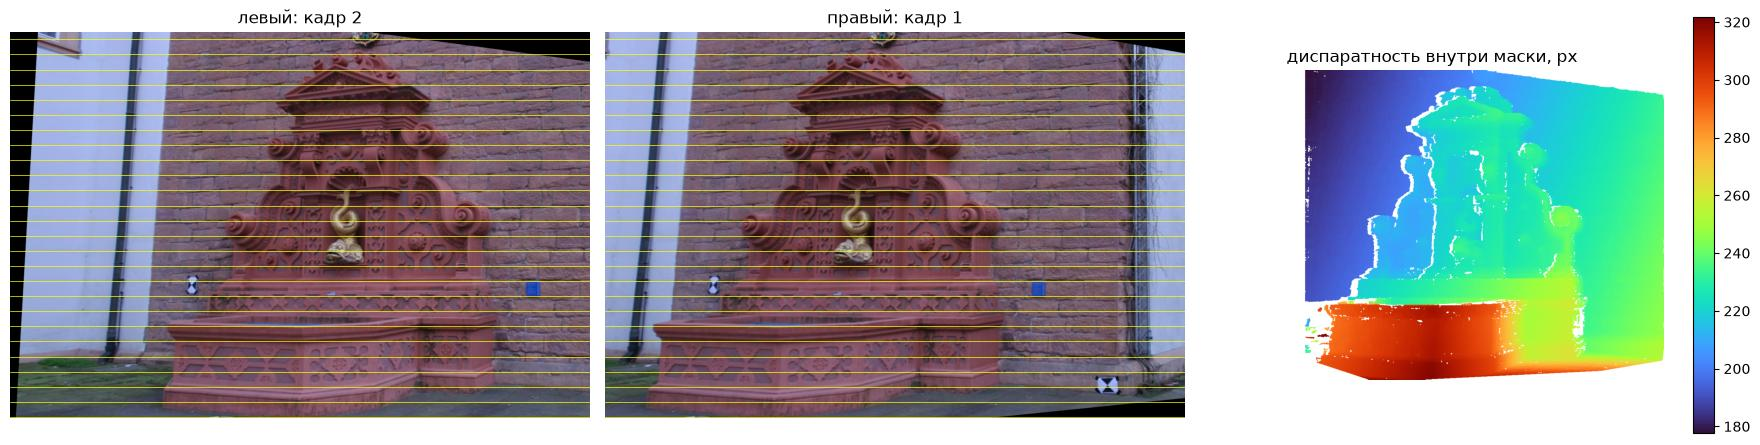

In [21]:
# пара с наибольшим числом точек: ректифицированные кадры (соответствующие точки — на одной строке) и диспаратность
pair_debug = max(debug, key=lambda d: np.isfinite(d["disparity"]).sum())
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
ax[0].imshow(pair_debug["left"]); ax[1].imshow(pair_debug["right"])
for a in ax[:2]:
    for y in range(20, pair_debug["left"].shape[0], 40):
        a.axhline(y, color="yellow", lw=0.5)
    a.axis("off")
ax[0].set_title(f"левый: кадр {pair_debug['pair'][0]}"); ax[1].set_title(f"правый: кадр {pair_debug['pair'][1]}")
im = ax[2].imshow(pair_debug["disparity"], cmap="turbo"); plt.colorbar(im, ax=ax[2])
ax[2].set_title("диспаратность внутри маски, px"); ax[2].axis("off")
plt.tight_layout(); plt.show()

# плотное облако (на графике — подвыборка, всё облако — в dense.ply)
N_PLOT = 50000
sel = np.random.default_rng(0).choice(len(X_dense), min(N_PLOT, len(X_dense)), replace=False)
fig = go.Figure(go.Scatter3d(x=X_dense[sel, 0], y=X_dense[sel, 1], z=X_dense[sel, 2], mode="markers",
                             marker=dict(size=1.2, color=[f"rgb({r},{g},{b})" for r, g, b in C_dense[sel]])))
fig.update_layout(title=f"плотное облако: {len(X_dense)} точек (показано {len(sel)})", height=750,
                  margin=dict(l=0, r=0, t=40, b=0), scene=dict(aspectmode="data", camera=dict(up=dict(x=0, y=-1, z=0))))
fig.show()